# Distributions

<em>Well, it’s up in the mornin’ tryin’ to find a job of work<br>
Stand in one place till your feet begin to hurt<br>
If you got a lot o’ money you can make yourself a'merry<br>
If you only got a nickel, it’s the Staten Island Ferry</em><br>
\- Bob Dylan, <em><a href="https://www.youtube.com/watch?v=QbmWcHW8xR4" target="_blank">Hard Times in New York Town</a></em>

Welcome to New York! We'll begin our journey by getting to know one of the world's great global cities through the lens of statistics, starting with a survey of statistical distributions.

In [1]:
# This cell helps define the plot style for the rest of the notebook.
# I've taken some of my own liberties with regards, to style, but am
# heavily indebted to the the tufte.css style guide for much of the
# plotting & general layout of this JupyterBook.

# Check them out at: https://edwardtufte.github.io/tufte-css/

import numpy as np
import matplotlib.pyplot as plt

from matplotlib import rcParams, cycler
from matplotlib.font_manager import findfont, FontProperties

font_stack = ['et-book', 'Palatino', 'Palatino Linotype', 'Palatino LT STD', 
              'Book Antiqua', 'Georgia', 'DejaVu Serif']

def get_available_font():
    for font in font_stack:
        try:
            if findfont(FontProperties(family=font)) is not None:
                return font
        except:
            continue
    return 'DejaVu Serif'

selected_font = get_available_font()

# Create a custom style dictionary with transparent elements
dark_theme = {
    # Figure and background
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    
    # Save with transparent background
    'savefig.transparent': True,
    
    # Font settings
    'font.family': 'serif',
    'font.serif': [selected_font],
    'font.size': 12,
    'font.weight': 250,
    
    # Grid settings
    'grid.color': '#FFFFFF',
    'grid.alpha': 0.3,
    
    # Text colors
    'text.color': '#ddd',
    'axes.labelcolor': '#ddd',
    'xtick.color': '#ddd',
    'ytick.color': '#ddd',
    
    # Edge colors
    'axes.edgecolor': '#ddd',
    
    # Line colors
    'axes.prop_cycle': cycler(color=[
        '#D1B675',
        '#93C5FD',
        '#B91C1C',
        '#d1d1d1',
        '#C3FF5B',
        '#FF88FF',  
        '#FFD700',  
        '#8BE9FD'   
    ])
}

# Apply the custom style
plt.style.use('dark_background')
plt.rcParams.update(dark_theme)

## What Do Distributions Tell Us About Cities?

Cities are symphonies of interaction - people stride through streets, businesses open and close, neighbors gossip, strangers meet on a first date, delivery vehicles weave through alleys, and somewhere, always, a toilet flushes. At first glance, these urban phenomena might appear to be chaotic, defying systemic analysis. Yet beneath the apparent cacophony often lies remarkable regularity that we can attempt to understand through the mathematical framework of statistics.<br>

At its core, a statistical distribution represents our understanding of how values vary across a population. They allow us to describe and understand our data in a systematic way, and form the basis of a many of the predictive methods we'll tackle later.

<em>What fraction of buildings in Manhattan exceed 20 stories? How long do people wait for buses in Queens? How much can I hope to earn next year if I open a coffee shop in Bed Stuy?</em> Questions like these are fundemental to the understanding of urban life, and find their answers in the shapes and patterns of statistical distributions.

```{margin} 
<em><sup>*</sup>"All models are wrong, but some are useful" - George Box, British Statistician</em>
```
Alas, data rarely come pre-packaged with labels stating "<em>I am a Gamma Distribution.</em>" In the real world, data are often messy, raw and discordant. Indeed, it can be convincingly argued that probability distributions <a href="https://www.nature.com/articles/d41586-024-04096-5" target="_blank">don't even exist</a>! (Although it can't be convincingly argued that they aren't useful!<sup>*</sup>)

The act of matching data with a distribution tells us something fundemental about how the data originate. When we discover that wait times at intersection crossings follow an exponential distribution, we're uncovering more than a pattern - we're revealing the underlying mechanics of urban movement, helping build a framework that help us understand why these patterns emerge and how they might change under different conditions. This knowledge becomes invaluable for urban planning, policy-making, and the design of more livable cities.

The distribution of new building heights, for example, likely reflect a dialog between engineering constraints, economic forces, and government regulation. Changes to any of these dimensions - say the development of reliable <a href="https://www.dezeen.com/2021/07/30/henn-tu-dresden-carbon-fibre-concrete-building/" target="_blank">carbon fibre reinforced concrete<a> or <a href="https://www.treehugger.com/single-stair-buildings-united-states-5197036" target="_blank">to building fire codes</a> - could have a notable impact on the distribution of new building heights.

Normal distributions often emerge from the cumulative effect of many independent, small influences, while power law distributions typically arise in systems shaped by preferential attachment or disproportionate reinforcement of advantage (aka "winner take all" scenarios).
```{margin} 
<em><sup>*</sup> Seemingly unrelated systems, such as vascular & transport networks display remarkable similarities, as we'll explore in Chapter 5.</em>
```
What makes distributions particularly powerful is their universality. Similar patterns often emerge across different cities and cultures<sup>*</sup>, suggesting fundamental principles underlying urban organization. A distribution of retail store sizes in New York might mirror one in Tokyo, hinting at common economic principles at work. Yet the parameters of these distributions – their precise shapes and values – can reveal crucial differences between cities, neighborhoods, or time periods.

## A Tour of Common Distributions

Many statistics texts start with descriptive statistics (mean, standard deviation, etc.) before working up to distributions. While this may suit some introductory courses, I find it unintuitive. Descriptive statistics are imporant simplifications, but understanding when they're appropriate and what they're simplifying is critical, and something that I see this mistaken all too often in practice. Given most readers will know what a "mean" is, I feel strongly that starting with distributions is a more appropriate approach here.

Most statistics books also clearly divide "discrete" & "continuous" distributions. While we'll address these differences in various contexts, given the generally large-scale of data used in modern data science, this is not a fundemental distinction for most practical purposes.

The best way to build intuition is to see examples and practice. Below, I've outlined a handful of statistical distributions that I believe an Urban Data Scientist should have some working familiarty with. I particularly focus on <em>why</em> these distributions emerge -- they are not simply formulae to memorize, but clues that point us towards a deeper understanding of the underlying process. If we're a little clever, this can help us not only predict future values, but allow us to imagine, foster, and engineer better urban systems.

We'll start with an overview of the distributions themselves, looking at an example or two for each. We'll then dive into how to evaluate whether our data match a given distribution. Loosely speaking, when we're dealing with known, idealized distributions, we call this "Probability"; when we're evaluating how to fit messy, real-world data to an idealized pattern and understanding the uncertainty involved in this fitting, this is called "Statistics."

What follows can, admittedly, be a bit dense. It's not meant to be fully digested in one sitting; rather, try to pull away the key points and develop a brief intuition about each distribution - look for the <em>why</em>. Then go out in the world, observe various phenomena, and try to see if you can identify the associated distribution.

### Uniform Distributions

```{margin} 
<em><sup>*</sup> If you want to annoy your friends, next time you're asked to pick a random number between 1 and 100, ask them which distribution they'd like you to sample from.</em>
```
The Uniform Distribution is the most basic of distributions; it is often what is colloquially meant when someone says "random<sup>*</sup>." It assumes that all values between two end points are equally likely. 

Despite this colloquial association with 'randomness,' uniform distributions are remarkably uncommon in the real world. Uniformity typically appears only when humans deliberately impose it through design or regulation.

When we encounter uniform distributions in cities, they often tell us something about human intervention - about our attempts to impose order on urban chaos, whether through zoning laws, transit scheduling, or urban planning guidelines.

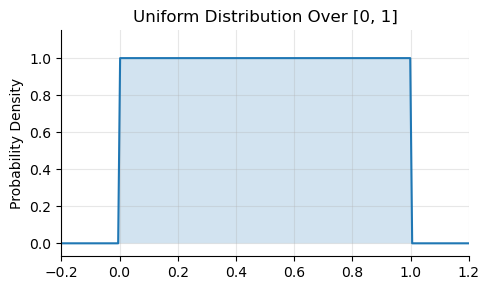

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import uniform

# Define the parameters
loc = 0
scale = 1

# Create a uniform distribution instance
dist = uniform(loc, scale)

# Generate x values that span a bit beyond the interval to see the boundaries clearly
x = np.linspace(-0.5, 1.5, 300)

# Compute the PDF values for these x values
pdf_values = dist.pdf(x)

# Create the plot
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, pdf_values, label='Uniform PDF')
ax.fill_between(x, pdf_values, alpha=0.2)
ax.set_ylim(-0.07, 1.15)
ax.set_xlim(-0.2, 1.2)
ax.set_title('Uniform Distribution Over [0, 1]')
ax.set_ylabel('Probability Density')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Mathematical Foundations & Assumptions
The Uniform distribution describes a variable equally likely to take any value within an interval $[a,b]$. It's defined by just two parameters:

$a$: minimum value<br>
$b$: maximum value

And has a probability density function (PDF) of:

$$
f(x) =
\begin{cases} 
\frac{1}{b-a} & \text{if } x \in [a,b], \\
0 & \text{otherwise}.
\end{cases}
$$

Key assumptions:
* Constant probability density throughout the interval
* Zero probability outside the interval
* All intervals of equal length have equal probability

#### In Urban Systems
Uniform distributions do not occur often in the natural world (which prefers normal & long-tail distributions), but we'll see them come up in some urban contexts. Examples could include things like evenly spaced blocks in a city grid, the spatial distribution of trees or lampposts in a park, or temporal events like the likelyhood of a bus arriving at any minute in an interval.


### Normal Distributions
#### Mathematical Foundations and Assumptions
The normal distribution arises from the Central Limit Theorem, which tells us that when many small, independent factors contribute additively to a phenomenon, their sum tends toward a normal distribution. Mathematically, it's defined by two parameters: the mean (μ) and standard deviation (σ). The distribution is symmetric, with about 68% of observations falling within one standard deviation of the mean.
The key assumptions include:

* The variable can take any real value (positive or negative)
* The distribution is symmetric around its mean
* Small deviations from the mean are more common than large ones
* The mean, median, and mode are identical

#### Emergence in Urban Systems
The normal distribution appears in urban systems when multiple independent factors contribute to a measurement. Consider pedestrian walking speeds: numerous factors affect an individual's pace – age, fitness, purpose of trip, weather conditions, sidewalk conditions, etc. None of these factors dominates the others, and they combine additively to produce the final walking speed.<br>
Similarly, building floor areas within a specific category (like single-family homes built in the same decade) often follow a normal distribution because multiple independent decisions about room sizes, layouts, and configurations combine to determine the final area.

In [157]:
# https://data.cityofnewyork.us/resource/uvpi-gqnh.csv
import pandas as pd
from sodapy import Socrata

client = Socrata("data.cityofnewyork.us", None)

results = client.get(
    'uvpi-gqnh', 
    where="boroname = 'Brooklyn' AND health=='Good' AND curb_loc=='OnCurb' AND spc_common=='London planetree'",
    limit=50000)
census_df = pd.DataFrame.from_records(results)

In [158]:
census_df.head()

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council_district,census_tract,bin,bbl
0,189465,219493,2015-08-30T00:00:00.000,22,0,OnCurb,Alive,Good,Platanus x acerifolia,London planetree,...,3019100,New York,40.69473314,-73.96821054,993065.3039,192388.0651,35,191,3054331,3018880073
1,195265,227489,2015-09-01T00:00:00.000,19,0,OnCurb,Alive,Good,Platanus x acerifolia,London planetree,...,3044000,New York,40.61190461,-73.97042748,992460.7283,162211.1235,44,440,3173737,3065860055
2,193690,227528,2015-09-01T00:00:00.000,36,0,OnCurb,Alive,Good,Platanus x acerifolia,London planetree,...,3044000,New York,40.61366258,-73.97453014,991321.4501,162851.2413,44,440,3173500,3065820101
3,196132,206122,2015-09-02T00:00:00.000,19,0,OnCurb,Alive,Good,Platanus x acerifolia,London planetree,...,3043600,New York,40.61293798,-73.97671635,990714.5412,162587.0807,44,436,3172416,3065570055
4,192890,210568,2015-08-31T00:00:00.000,28,0,OnCurb,Alive,Good,Platanus x acerifolia,London planetree,...,3054800,New York,40.60991608,-73.94861133,998518.3471,161489.4477,48,548,3182701,3067870032


In [159]:
results = client.get(
    'hn5i-inap', 
    where="genusspecies = 'Platanus x acerifolia - London planetree'",
    limit=50000)
tree_df = pd.DataFrame.from_records(results)
tree_df

,objectid,dbh,tpstructure,tpcondition,stumpdiameter,plantingspaceglobalid,geometry,globalid,genusspecies,createddate,location,updateddate,riskrating,riskratingdate,planteddate
0,3998513,30,Full,Good,0,BC03E631-E7BC-4CBC-A527-DBAFD4C096EF,POINT (-73.7605065374450959 40.6737728798577791),42053751-58A9-4A90-BCE4-8993B31A2EF7,Platanus x acerifolia - London planetree,2016-06-30 09:56:53.0000000,"{'type': 'Point', 'coordinates': [-73.76050653...",NaN,NaN,NaN,NaN
1,399902,23,Full,Fair,NaN,8E63A8A7-7A3B-4A3C-98E6-878993F4A316,POINT (-73.9289658115138906 40.6573743372592560),83AA1B67-092B-4F00-9B00-5316DF6404B9,Platanus x acerifolia - London planetree,2015-08-13 13:52:00.0000000,"{'type': 'Point', 'coordinates': [-73.92896581...",2024-04-05 13:26:15.0000000,8,2024-04-05 13:26:15.0000000,NaN
2,337012,23,Full,Fair,NaN,DDC41F78-C7DA-4315-9CEB-0E190956EFC3,POINT (-73.8531333236339833 40.6733320048090050),3E23FD5C-EC14-47F1-B5B8-ABB1F049037C,Platanus x acerifolia - London planetree,2015-08-04 11:06:00.0000000,"{'type': 'Point', 'coordinates': [-73.85313332...",2023-11-28 16:45:34.0000000,7,2023-11-28 16:45:34.0000000,NaN
3,114825,18,Full,Fair,NaN,BDF9D249-AA4B-4C9B-9457-29ED302085EA,POINT (-74.0928742325570084 40.5930125960126986),C2D36AAE-B9BC-4F39-8C3B-1A6F63EB25B8,Platanus x acerifolia - London planetree,2015-03-24 04:00:00.0000000,"{'type': 'Point', 'coordinates': [-74.09287423...",2024-08-09 18:46:02.0000000,6,2024-08-09 18:46:02.0000000,NaN
4,234181,4,Retired,Dead,24,79BB2D0B-5216-4B56-A164-4027BF8A401A,POINT (-73.9193386910299068 40.7017198895844317),0FE41277-84E9-420B-A757-C5FAF674D771,Platanus x acerifolia - London planetree,2015-06-26 12:59:00.0000000,"{'type': 'Point', 'coordinates': [-73.91933869...",2017-04-13 11:11:11.0000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,3253760,12,Retired,Dead,NaN,ED79CEE2-B127-4E63-A778-FF2313E6B2A1,POINT (-73.9876167643131453 40.6605180683253309),204429B7-180F-45BB-950E-75194C1D55DA,Platanus x acerifolia - London planetree,2016-05-06 12:38:00.0000000,"{'type': 'Point', 'coordinates': [-73.98761676...",2019-03-21 19:16:42.0000000,9,2016-05-06 12:38:31.0000000,NaN
49996,3135266,19,Full,Fair,NaN,8272A21C-F4A3-40E9-B9C1-78B928FAED1D,POINT (-73.9467706449529487 40.5758922370975839),8B707D13-23BD-42B0-94C1-38AF6F39E4DB,Platanus x acerifolia - London planetree,2016-04-18 13:37:57.0000000,"{'type': 'Point', 'coordinates': [-73.94677064...",2023-06-26 17:21:59.0000000,9,2023-06-26 17:21:59.0000000,NaN
49997,3347671,20,Full,Good,NaN,E89FF068-17C1-4B77-A49C-D4BE6353E590,POINT (-73.9850356647811225 40.6837405173183200),DFF9402D-7B43-413D-9AE7-D957B49DEE7F,Platanus x acerifolia - London planetree,2016-05-11 20:04:15.0000000,"{'type': 'Point', 'coordinates': [-73.98503566...",2024-06-13 00:53:58.0000000,5,2024-06-13 00:53:58.0000000,NaN
49998,3190943,13,Retired,Dead,16,120629B1-6668-4513-90A4-0DCC19ABD1E1,POINT (-73.9458523768945497 40.5765730391598183),948C6208-1E28-4EAA-AC72-C6149B0B51A6,Platanus x acerifolia - London planetree,2016-04-27 11:13:00.0000000,"{'type': 'Point', 'coordinates': [-73.94585237...",2017-05-24 15:24:22.0000000,NaN,NaN,NaN


In [162]:
m_df = tree_df.merge(census_df, how='inner', right_on='tree_id', left_on='objectid')

In [169]:
m_df.tpcondition.value_counts

<bound method IndexOpsMixin.value_counts of 0           Good
1           Good
2           Fair
3      Excellent
4           Good
         ...    
238         Good
239         Fair
240         Fair
241         Good
242         Good
Name: tpcondition, Length: 243, dtype: object>

In [99]:
import seaborn as sns

<Axes: xlabel='tree_dbh', ylabel='Count'>

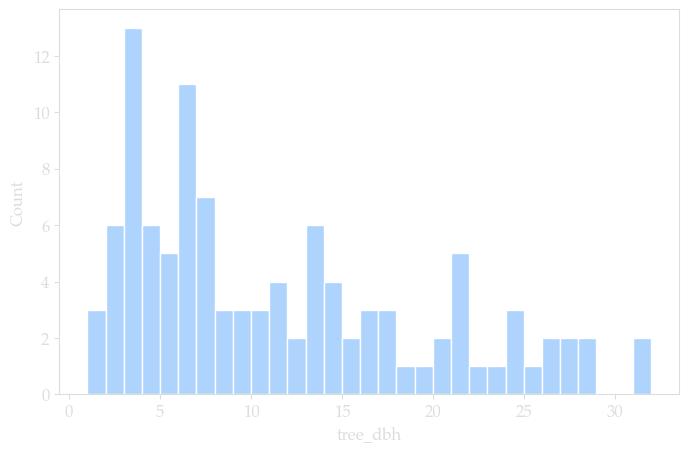

In [147]:
bk_tree_df = results_df[
    (results_df.boroname=='Brooklyn')
    & (results_df.tree_dbh.astype(int)<=41)
    & (results_df.spc_common=='London planetree')
    & (results_df.guards=='None')
    # & (results_df.spc_common=='tree of heaven')
    ].copy()

f, ax = plt.subplots(figsize=(8, 5))
sns.histplot(bk_tree_df.tree_dbh.astype(int), binwidth=1)

In [ ]:
tree_id

In [145]:
bk_tree_df.guards.value_counts()

guards
None       12012
Helpful      689
Harmful      287
Unsure       137
Name: count, dtype: int64

In [125]:
for i in results_df.spc_common.value_counts().index:
    print(i)
# spc_common
# status
# curb_loc
# Diameter of the tree, measured at approximately 54" / 137cm above the ground. 

London planetree
honeylocust
pin oak
Japanese zelkova
Callery pear
littleleaf linden
Sophora
ginkgo
cherry
Norway maple
American linden
green ash
swamp white oak
American elm
northern red oak
silver linden
sweetgum
red maple
Chinese elm
silver maple
'Schubert' chokecherry
Kentucky coffeetree
purple-leaf plum
dawn redwood
golden raintree
Japanese tree lilac
crimson king maple
sawtooth oak
willow oak
Amur maackia
eastern redbud
bald cypress
crab apple
English oak
hedge maple
scarlet oak
Schumard's oak
common hackberry
white oak
hawthorn
sycamore maple
sugar maple
black oak
European hornbeam
Siberian elm
black locust
maple
hardy rubber tree
ash
American hornbeam
flowering dogwood
serviceberry
American hophornbeam
white ash
eastern redcedar
shingle oak
Amur maple
tulip-poplar
Cornelian cherry
katsura tree
mulberry
tree of heaven
black cherry
bur oak
horse chestnut
Japanese hornbeam
paper birch
river birch
blackgum
silver birch
Kentucky yellowwood
Japanese maple
black walnut
Atlantic white 

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import rcParams, cycler
from matplotlib.font_manager import findfont, FontProperties

font_stack = ['et-book', 'Palatino', 'Palatino Linotype', 'Palatino LT STD', 
              'Book Antiqua', 'Georgia', 'DejaVu Serif']

def get_available_font():
    for font in font_stack:
        try:
            if findfont(FontProperties(family=font)) is not None:
                return font
        except:
            continue
    return 'DejaVu Serif'

selected_font = get_available_font()

# Create a custom style dictionary with transparent elements
dark_theme = {
    # Figure and background
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    
    # Save with transparent background
    'savefig.transparent': True,
    
    # Font settings
    'font.family': 'serif',
    'font.serif': [selected_font],
    'font.size': 12,
    'font.weight': 250,
    
    # Grid settings
    'grid.color': '#FFFFFF',
    'grid.alpha': 0.3,
    
    # Text colors
    'text.color': '#ddd',
    'axes.labelcolor': '#ddd',
    'xtick.color': '#ddd',
    'ytick.color': '#ddd',
    
    # Edge colors
    'axes.edgecolor': '#ddd',
    
    # Line colors
    'axes.prop_cycle': cycler(color=[
        '#93C5FD',
        '#D1B675',
        '#d1d1d1',
        '#B91C1C',
        '#C3FF5B',
        '#FF88FF',  
        '#FFD700',  
        '#8BE9FD'   
    ])
}

# Apply the custom style
plt.style.use('dark_background')
plt.rcParams.update(dark_theme)

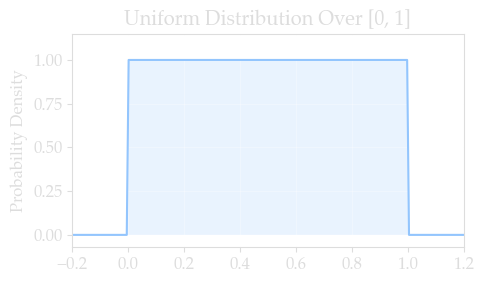

Expected Mean: 5.0
Expected Variance: 8.333333333333334
KS Test Statistic: 0.02391253466587384
KS p-value: 0.6080449188690945
Chi-Square Statistic: 10.283999999999999
Chi-Square p-value: 0.41594033172331346


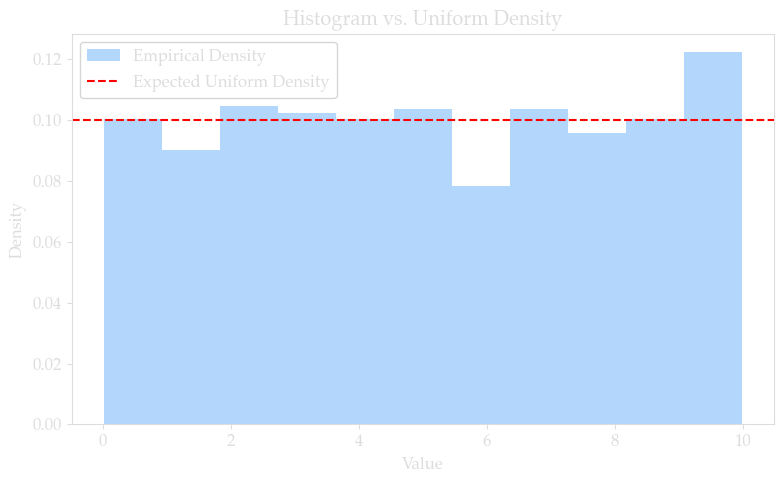

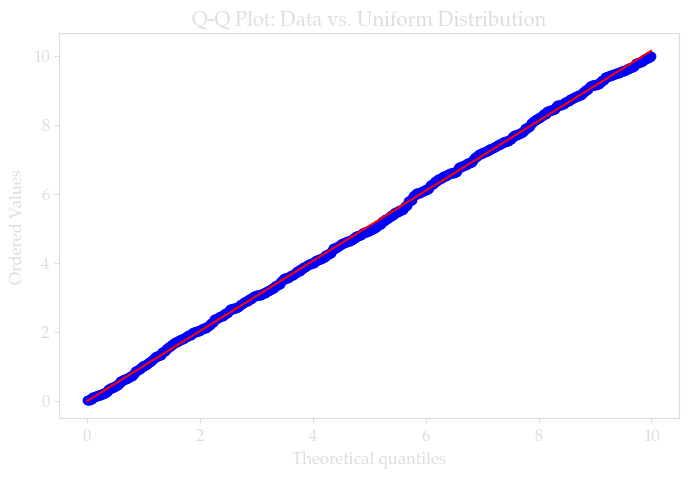

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- Simulate Uniform Data over [a, b] ---
a, b = 0, 10
data = np.random.uniform(a, b, size=1000)
data_range = b - a

# Expected statistics
expected_mean = (a + b) / 2
expected_var = (data_range ** 2) / 12

print("Expected Mean:", expected_mean)
print("Expected Variance:", expected_var)

# --- Kolmogorov-Smirnov (KS) Test ---
# When testing, note that scipy.stats.uniform is defined with parameters: loc=a, scale=b-a.
ks_stat, ks_p = stats.kstest(data, 'uniform', args=(a, data_range))
print("KS Test Statistic:", ks_stat)
print("KS p-value:", ks_p)

# --- Chi-Square Test ---
# Use a histogram to compare observed counts to the expected uniform counts.
hist, bin_edges = np.histogram(data, bins='auto')
chi2_stat, chi2_p = stats.chisquare(hist)
print("Chi-Square Statistic:", chi2_stat)
print("Chi-Square p-value:", chi2_p)

# --- Plotting: Histogram vs. Expected Uniform Density ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data, bins='auto', density=True, alpha=0.7, label='Empirical Density')
ax.axhline(y=1/data_range, color='r', linestyle='--', label='Expected Uniform Density')
ax.set_title('Histogram vs. Uniform Density')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

# --- Plotting: Q-Q Plot ---
# Compare the quantiles of the observed data to those of a uniform distribution.
fig, ax = plt.subplots(figsize=(8, 5))
stats.probplot(data, dist=stats.uniform(loc=a, scale=data_range), plot=ax)
ax.set_title('Q-Q Plot: Data vs. Uniform Distribution')
plt.show()

In [5]:
def estimate_uniform_parameters(data, method='mle', trim_quantile=0.01):
    """
    Estimate parameters for a uniform distribution.
    
    Parameters:
        data (array-like): Observations.
        method (str): 'mle' (default), 'robust', or 'bayesian'.
        trim_quantile (float): Quantile for trimming in robust estimation.
        
    Returns:
        tuple: (a, b) estimates.
    """
    data = np.asarray(data)
    if method == 'mle':
        return np.min(data), np.max(data)
    elif method == 'robust':
        lower = np.quantile(data, trim_quantile)
        upper = np.quantile(data, 1 - trim_quantile)
        return lower, upper
    elif method == 'bayesian':
        # A simplistic Bayesian approach with an uninformative prior.
        n = len(data)
        return np.min(data) - np.min(data)/n, np.max(data) + np.max(data)/n
    else:
        raise ValueError("Method must be 'mle', 'robust', or 'bayesian'")

a_est, b_est = estimate_uniform_parameters(data, method='mle')
print("Estimated parameters: a =", a_est, ", b =", b_est)

Estimated parameters: a = 0.00855965570862205 , b = 9.992375777355868


In [6]:
def test_uniformity(data, alpha=0.05):
    """
    Tests the hypothesis that data come from a uniform distribution.
    
    Parameters:
        data (array-like): Observations.
        alpha (float): Significance level.
        
    Returns:
        dict: Test statistics and a boolean flag for uniformity.
    """
    data = np.asarray(data)
    a, b = np.min(data), np.max(data)
    data_range = b - a
    # Scale data to [0,1]
    scaled_data = (data - a) / data_range
    
    # KS Test for uniformity on [0,1]
    ks_stat, ks_p = stats.kstest(scaled_data, 'uniform')
    
    # Chi-square Test using histogram counts
    hist, _ = np.histogram(scaled_data, bins='auto')
    chi2_stat, chi2_p = stats.chisquare(hist)
    
    return {
        'ks_test': {'statistic': ks_stat, 'p_value': ks_p},
        'chi_square': {'statistic': chi2_stat, 'p_value': chi2_p},
        'is_uniform': (ks_p > alpha) and (chi2_p > alpha)
    }

results = test_uniformity(data)
print("Uniformity Test Results:", results)

Uniformity Test Results: {'ks_test': {'statistic': 0.024413447218922024, 'p_value': 0.5816025419125916}, 'chi_square': {'statistic': 10.283999999999999, 'p_value': 0.41594033172331346}, 'is_uniform': True}


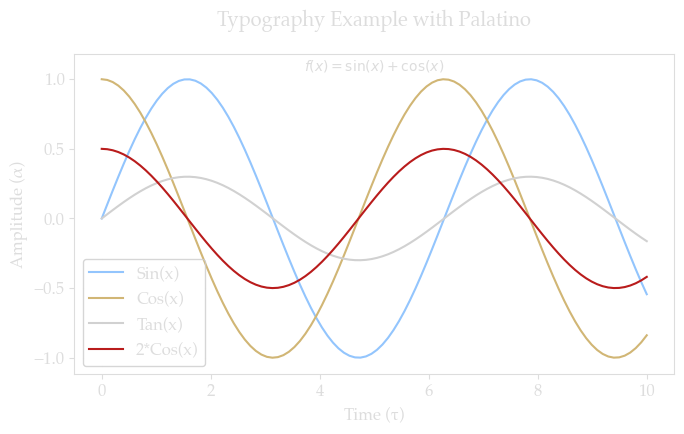

In [14]:
def create_plot():
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    # Generate some sample data
    x = np.linspace(0, 10, 100)
    ax.plot(x, np.sin(x), label='Sin(x)')
    ax.plot(x, np.cos(x), label='Cos(x)')
    ax.plot(x, 0.3 * np.sin(x), label='Tan(x)')
    ax.plot(x, 0.5 * np.cos(x), label='2*Cos(x)')
    
    # Demonstrate various text elements
    ax.set_title('Typography Example with ' + selected_font, pad=20)
    ax.set_xlabel('Time (τ)')  # Using Greek letter
    ax.set_ylabel('Amplitude (α)')  # Using Greek letter
    
    # Add some mathematical notation
    ax.text(0.5, 0.95, r'$f(x) = \sin(x) + \cos(x)$', 
            transform=ax.transAxes, 
            fontsize=10, 
            horizontalalignment='center')
    
    ax.grid(True, alpha=0.2)
    ax.set_ylim(-1.12, 1.18)
    ax.legend(framealpha=0.8)
    
    plt.tight_layout()
    plt.show()

create_plot()

https://medium.com/nycwater/the-big-flush-on-super-bowl-sunday-e0050699fa1b

We'll begin our journey in New York

Why start with distributions? Generally, they're the truth that descriptive statistics is trying to describe. Before simply looking at a mean, median, or 95th percentile of a dataset, we should know a few things about the underlying distribution that it's likely coming from. <br><br>
The goal here is to understand what these distributions are, and how to apply them in the context of cities. We'll cover some of the math, but long proofs are not the main focus of this book.

Power Law Distribution

City size distributions (Zipf's Law)
Income distributions within cities
Business size distributions
Social network connections in urban areas


Poisson Distribution

Traffic arrivals at intersections
Public transit passenger arrivals
Service requests to city agencies
Crime incidents in neighborhoods
Emergency service calls


Normal Distribution

Housing prices (often log-normal)
Building heights
Commute times
Environmental measurements (air quality, noise levels)
Demographics (age distributions)


Exponential Distribution

Wait times (public services, transit)
Building age
Distance between urban amenities
Duration of parking occupancy


Weibull Distribution

Infrastructure failure rates
Building lifetime/deterioration
Peak energy demand patterns
Extreme weather events affecting urban systems


Beta Distribution

Proportions of land use types
Demographic ratios
Satisfaction scores with urban services
Environmental quality indices


Gamma Distribution

Rainfall patterns affecting urban drainage
Travel time reliability
Energy consumption patterns
Property values

Negative Binomial Distribution

Clustering of urban phenomena (retail locations)
Repeat service calls from same address
Traffic accidents at specific intersections
Multiple trips to same destination
More flexible than Poisson for "overdispersed" count data


Log-logistic Distribution

Property sale times
Infrastructure project completion times
Innovation diffusion through cities
Urban-rural migration patterns


Multinomial Distribution

Modal split in transportation
Housing type distributions
Land use classification
Occupation distributions across neighborhoods
Voting patterns by district


Student's t-Distribution

Small sample urban indicators
Neighborhood-level statistics
Quality of life measurements
Air quality sampling with limited sensors


Geometric Distribution

Number of attempts until successful housing match
Bus bunching patterns
Sequential vacancy fillings
Time until infrastructure failure


Zero-Inflated Distribution (modification of count distributions)

Bike-share usage at stations
Parking violations
Business complaints
Many urban phenomena with excess zeros


Hypergeometric Distribution

Sampling without replacement in urban audits
Demographic representation in city services
School assignment processes
Resource allocation across districts

Burr Distribution (versatile for skewed data)

Income inequality within neighborhoods
Property size distributions
Urban-rural wealth gradients
Business revenue distributions
More flexible than log-normal for heavy tails


Discrete Uniform Distribution

Floor numbers in buildings
Public transit route numbers
Administrative district numbering
Parking space assignments
Random sampling in urban audits


Gumbel Distribution (extreme value type I)

Maximum daily traffic flows
Extreme temperature events
Peak urban flooding levels
Maximum daily energy demand
Urban heat island extremes


Bivariate Normal Distribution

Spatial distribution of urban amenities
Crime hotspot analysis
Pedestrian movement patterns
Air pollution dispersion
Spatial correlation in housing prices

Log-Normal Distribution

House prices and real estate values (one of the most classic applications)
City sizes (alternative to power law/Zipf's - ongoing debate in urban scaling literature)
Income distributions within cities (especially when looking at smaller geographic units)
Business sizes (number of employees, revenue)
Building heights
Commute distances (due to multiplicative effects of choices)
Rent prices
Land parcel sizes
Population density variations

## Further Reading
* [Statistical Distributions](https://pages.stern.nyu.edu/~adamodar/New_Home_Page/StatFile/statdistns.htm)
* [Understanding Moments](https://gregorygundersen.com/blog/2020/04/11/moments/)
* [Gaussians](https://gestalt.ink/gaussians)
* [Lognormal Distribution](https://gregorygundersen.com/blog/2023/12/17/lognormal/)

## Chapter 1: Distributions in the City

### 1.1 Understanding Statistical Distributions
A statistical distribution describes how values of a variable are distributed. It provides a function that shows the possible values for a variable and how often they occur. Understanding the underlying distribution of data is crucial for:

* Modeling and Prediction: Choosing the right distribution improves the accuracy of models.
* Hypothesis Testing: Many statistical tests assume specific distributions.
* Risk Assessment: Knowing the distribution helps in estimating probabilities of extreme events.

In urban contexts, distributions help us answer questions like:

* What is the probability that a taxi will have more than 10 rides in an hour?
* How likely is it for a building to exceed a certain height?
* What is the expected number of emergency calls during peak hours?

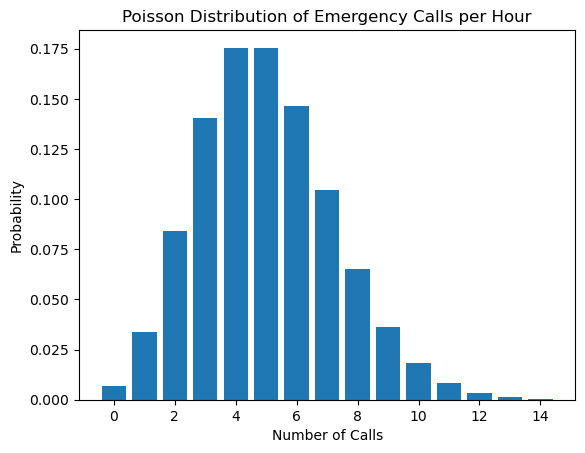

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Average number of emergency calls per hour
lambda_rate = 5

# Possible number of calls
k = np.arange(0, 15)

# PMF
pmf = poisson.pmf(k, lambda_rate)

plt.bar(k, pmf)
plt.title('Poisson Distribution of Emergency Calls per Hour')
plt.xlabel('Number of Calls')
plt.ylabel('Probability')
plt.show()

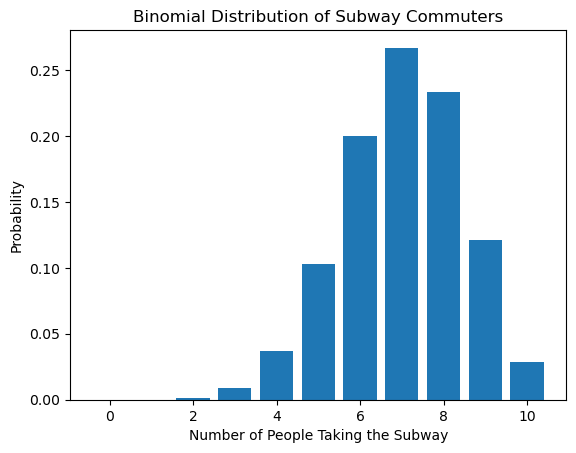

In [2]:
from scipy.stats import binom

# Number of trials (sample size)
n = 10
# Probability of success (taking the subway)
p = 0.7

# Possible number of successes
k = np.arange(0, n + 1)

# PMF
pmf = binom.pmf(k, n, p)

plt.bar(k, pmf)
plt.title('Binomial Distribution of Subway Commuters')
plt.xlabel('Number of People Taking the Subway')
plt.ylabel('Probability')
plt.show()

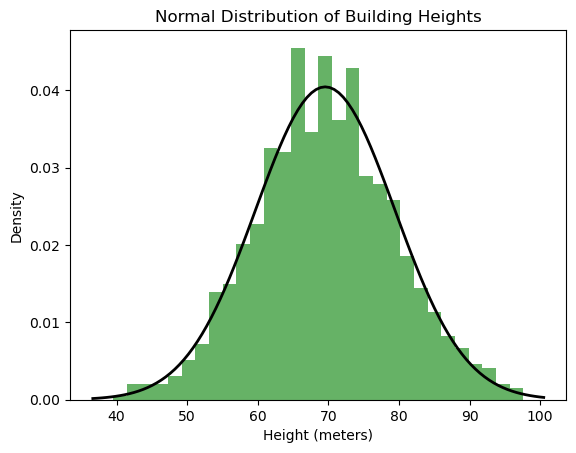

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Sample data: Building heights (in meters)
np.random.seed(0)
building_heights = np.random.normal(loc=70, scale=10, size=1000)

# Plotting the histogram and PDF
plt.hist(building_heights, bins=30, density=True, alpha=0.6, color='g')

# Plot the PDF
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, building_heights.mean(), building_heights.std())
plt.plot(x, p, 'k', linewidth=2)
plt.title('Normal Distribution of Building Heights')
plt.xlabel('Height (meters)')
plt.ylabel('Density')
plt.show()

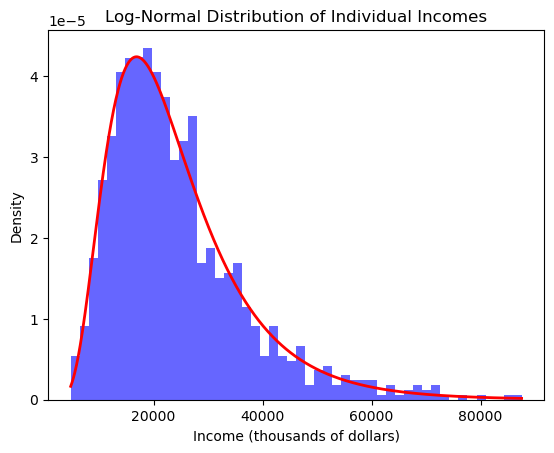

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Sample data: Individual incomes (in thousands of dollars)
np.random.seed(0)
incomes = np.random.lognormal(mean=10, sigma=0.5, size=1000)

# Plotting the histogram
plt.hist(incomes, bins=50, density=True, alpha=0.6, color='b')

# Plot the PDF
shape, loc, scale = lognorm.fit(incomes, floc=0)
x = np.linspace(min(incomes), max(incomes), 1000)
pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)
plt.plot(x, pdf, 'r', linewidth=2)
plt.title('Log-Normal Distribution of Individual Incomes')
plt.xlabel('Income (thousands of dollars)')
plt.ylabel('Density')
plt.show()

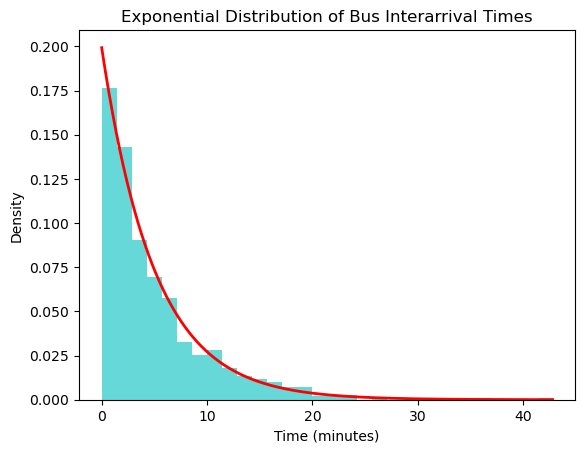

In [5]:
from scipy.stats import expon

# Sample data: Time between bus arrivals (in minutes)
np.random.seed(0)
interarrival_times = np.random.exponential(scale=5, size=1000)

# Plotting the histogram
plt.hist(interarrival_times, bins=30, density=True, alpha=0.6, color='c')

# Plot the PDF
x = np.linspace(0, max(interarrival_times), 1000)
pdf = expon.pdf(x, scale=interarrival_times.mean())
plt.plot(x, pdf, 'r', linewidth=2)
plt.title('Exponential Distribution of Bus Interarrival Times')
plt.xlabel('Time (minutes)')
plt.ylabel('Density')
plt.show()

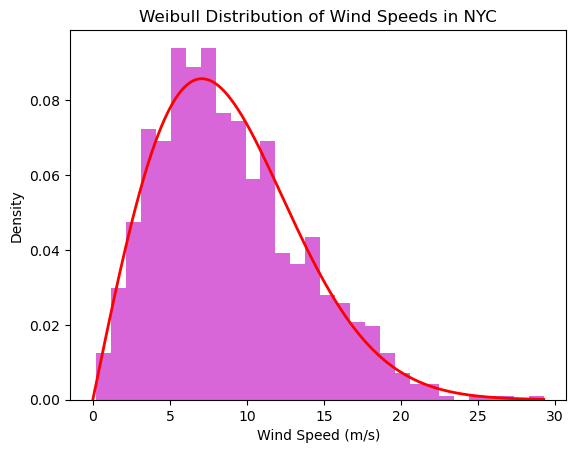

In [6]:
from scipy.stats import weibull_min

# Sample data: Wind speeds (in m/s)
np.random.seed(0)
wind_speeds = weibull_min.rvs(c=2, scale=10, size=1000)

# Plotting the histogram
plt.hist(wind_speeds, bins=30, density=True, alpha=0.6, color='m')

# Plot the PDF
x = np.linspace(0, max(wind_speeds), 1000)
pdf = weibull_min.pdf(x, c=2, scale=10)
plt.plot(x, pdf, 'r', linewidth=2)
plt.title('Weibull Distribution of Wind Speeds in NYC')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Density')
plt.show()

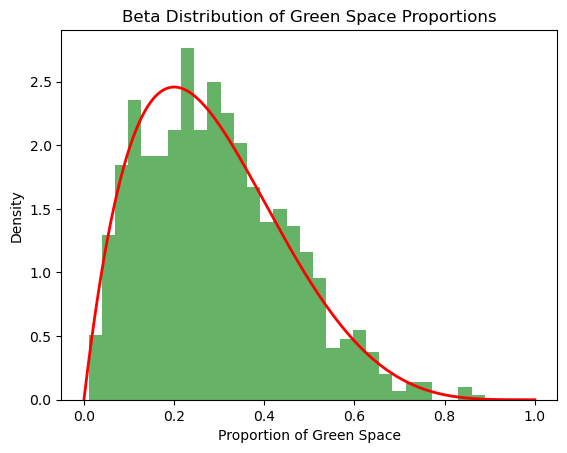

In [7]:
from scipy.stats import beta

# Sample data: Proportion of green space
np.random.seed(0)
green_space = beta.rvs(a=2, b=5, size=1000)

# Plotting the histogram
plt.hist(green_space, bins=30, density=True, alpha=0.6, color='g')

# Plot the PDF
x = np.linspace(0, 1, 1000)
pdf = beta.pdf(x, a=2, b=5)
plt.plot(x, pdf, 'r', linewidth=2)
plt.title('Beta Distribution of Green Space Proportions')
plt.xlabel('Proportion of Green Space')
plt.ylabel('Density')
plt.show()

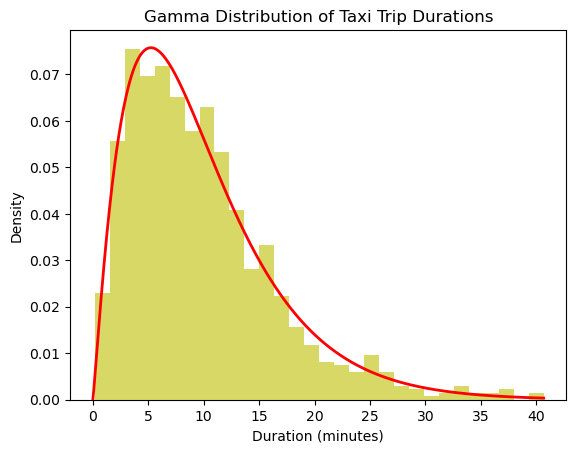

In [8]:
from scipy.stats import gamma

# Sample data: Taxi trip durations (in minutes)
np.random.seed(0)
trip_durations = gamma.rvs(a=2, scale=5, size=1000)

# Plotting the histogram
plt.hist(trip_durations, bins=30, density=True, alpha=0.6, color='y')

# Plot the PDF
x = np.linspace(0, max(trip_durations), 1000)
params = gamma.fit(trip_durations, floc=0)
pdf = gamma.pdf(x, *params)
plt.plot(x, pdf, 'r', linewidth=2)
plt.title('Gamma Distribution of Taxi Trip Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Density')
plt.show()

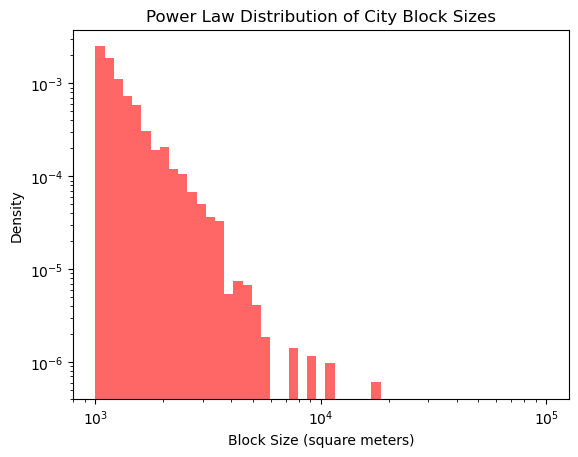

In [9]:
# Sample data: City block sizes (in square meters)
np.random.seed(0)
block_sizes = (np.random.pareto(a=3, size=1000) + 1) * 1000  # Shift and scale

# Plotting the histogram
counts, bins, _ = plt.hist(block_sizes, bins=np.logspace(np.log10(1000), np.log10(100000), 50), density=True, alpha=0.6, color='r')
plt.xscale('log')
plt.yscale('log')
plt.title('Power Law Distribution of City Block Sizes')
plt.xlabel('Block Size (square meters)')
plt.ylabel('Density')
plt.show()

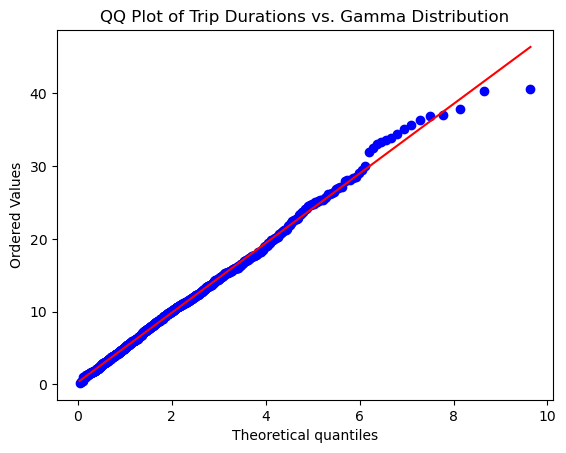

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Sample data: Taxi trip durations (in minutes)
np.random.seed(0)
trip_durations = gamma.rvs(a=2, scale=5, size=1000)

# QQ Plot against a gamma distribution
stats.probplot(trip_durations, dist="gamma", sparams=(2,), plot=plt)
plt.title('QQ Plot of Trip Durations vs. Gamma Distribution')
plt.show()

In [11]:
from scipy.stats import kstest, gamma

# Test if trip durations follow a gamma distribution
params = gamma.fit(trip_durations, floc=0)
ks_statistic, p_value = kstest(trip_durations, 'gamma', args=params)

print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

K-S Statistic: 0.015411635016448266
P-Value: 0.9685428012852954


In [12]:
# Fit different distributions
params_gamma = gamma.fit(trip_durations, floc=0)
params_lognorm = lognorm.fit(trip_durations, floc=0)
params_weibull = weibull_min.fit(trip_durations, floc=0)
params_expon = expon.fit(trip_durations, floc=0)

# Calculate log-likelihood
ll_gamma = np.sum(gamma.logpdf(trip_durations, *params_gamma))
ll_lognorm = np.sum(lognorm.logpdf(trip_durations, *params_lognorm))
ll_weibull = np.sum(weibull_min.logpdf(trip_durations, *params_weibull))
ll_expon = np.sum(expon.logpdf(trip_durations, *params_expon))

# Calculate AIC
aic_gamma = 2 * len(params_gamma) - 2 * ll_gamma
aic_lognorm = 2 * len(params_lognorm) - 2 * ll_lognorm
aic_weibull = 2 * len(params_weibull) - 2 * ll_weibull
aic_expon = 2 * len(params_expon) - 2 * ll_expon

print(f"AIC (Gamma): {aic_gamma}")
print(f"AIC (Log-Normal): {aic_lognorm}")
print(f"AIC (Weibull): {aic_weibull}")
print(f"AIC (Exponential): {aic_expon}")

AIC (Gamma): 6303.959436803516
AIC (Log-Normal): 6382.132524209535
AIC (Weibull): 6321.537562684305
AIC (Exponential): 6574.443081580004


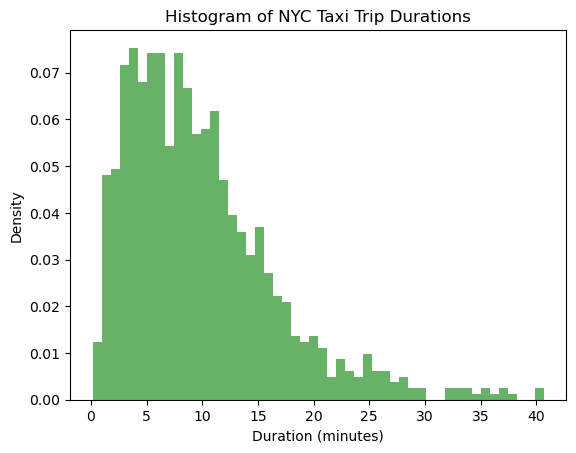

In [20]:
import pandas as pd
df = pd.DataFrame(trip_durations, columns=['trip_duration'])
trip_durations = df['trip_duration']

plt.hist(trip_durations, bins=50, density=True, alpha=0.6, color='g')
plt.title('Histogram of NYC Taxi Trip Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Density')
plt.show()

## Introduction

In urban data science, understanding statistical distributions is crucial for modeling and interpreting the diverse phenomena of a city. Different processes give rise to different distribution shapes – for example, the distribution of **daily subway ridership** might differ from that of **building heights** or **taxi trip distances**. In this chapter, we review common statistical distributions, focusing on those most relevant to urban systems. We use New York City (NYC) as a guiding example, drawing on city-themed scenarios (avoiding biased sources like 311 complaint data). Each distribution section includes: a narrative introduction, the mathematical foundation, relevance to an urban context, and a Python visualization (using `matplotlib` with a custom `dark_theme` style for consistency).

By the end, we will compare these distributions, noting typical use cases, assumptions, and limitations, as well as how to evaluate goodness-of-fit for real urban data. This will help in choosing appropriate models for city data and understanding what deviations from theoretical distributions imply about urban processes.

## Normal Distribution

The **Normal distribution** (or Gaussian) is perhaps the most well-known distribution in statistics. It arises naturally in many situations due to the Central Limit Theorem: roughly speaking, the sum (or average) of many independent random factors tends to be normally distributed&#8203;:contentReference[oaicite:0]{index=0}. Intuitively, if an urban measurement is influenced by many small independent effects (weather, individual decisions, random noise, etc.), the distribution of that measurement will often approach a bell-shaped normal curve. The normal distribution is symmetric and “unimodal” (single-peaked at the mean), with most values clustering around the average and probabilities for extreme deviations tapering off rapidly.

### Mathematical Foundation

A random variable $X$ is *Normal* (written $X \sim \mathcal{N}(\mu, \sigma^2)$) if its probability density function (PDF) is: 

$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\Big(-\frac{(x-\mu)^2}{2\sigma^2}\Big),
$$

for $-\infty < x < \infty$. Here $\mu$ is the mean (center of the distribution) and $\sigma^2$ the variance (spread). The normal curve is symmetric around $\mu$, and $\sigma$ determines the “width” of the bell (about 68% of values lie within $\mu\pm\sigma$, 95% within $\mu\pm2\sigma$, etc.). Because of its mathematical convenience and the ubiquity of the Central Limit Theorem, the normal distribution is a default model for many phenomena.

### Urban System Relevance

In the context of a city, a normal distribution often describes **fluctuations around an average behavior** or **measurement errors**. For example, if we repeatedly count pedestrians crossing a street at noon under similar conditions, the counts might vary approximately normally around some average due to many independent factors influencing each day’s count. Similarly, errors in sensors (like a traffic loop detector measuring cars per minute) are commonly modeled as normal noise around the true value. These situations involve aggregation of many small random influences, fitting the normal distribution’s generative story. However, it’s important to note that not every urban variable is normal – many have skewed or heavy-tailed distributions (discussed later). When a normal model is applicable, it provides a baseline: for instance, one might assume the residuals (unexplained errors) in a regression model of subway ridership are normally distributed, an assumption that underpins many statistical inference techniques.

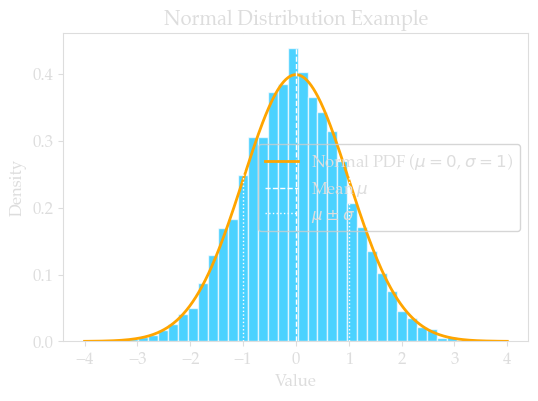

In [4]:
# Visualization for Normal distribution
# import numpy as np
# import matplotlib.pyplot as plt
from scipy.stats import norm

try:
    plt.style.use(dark_theme)
except NameError:
    plt.style.use('dark_background')

# Simulate a normal distribution (e.g., measurement errors with mean 0 and std 1)
mu, sigma = 0, 1
np.random.seed(0)
data = np.random.normal(mu, sigma, 10000)

# Plot histogram of data and theoretical PDF
x = np.linspace(mu-4*sigma, mu+4*sigma, 400)
pdf = norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(data, bins=40, density=True, color='deepskyblue', alpha=0.7, edgecolor='white')
ax.plot(x, pdf, color='orange', linewidth=2, label=f"Normal PDF ($\mu={mu}$, $\sigma={sigma}$)")
ax.axvline(mu, color='white', linestyle='--', linewidth=1, label="Mean $\mu$")
ax.axvline(mu+sigma, color='white', linestyle=':', linewidth=1, label="$\mu \pm \sigma$")
ax.axvline(mu-sigma, color='white', linestyle=':', linewidth=1)
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.set_title('Normal Distribution Example')
ax.legend()
plt.show()

In [21]:
mean_duration = trip_durations.mean()
variance_duration = trip_durations.var()
skewness_duration = trip_durations.skew()
kurtosis_duration = trip_durations.kurtosis()

print(f"Mean: {mean_duration}")
print(f"Variance: {variance_duration}")
print(f"Skewness: {skewness_duration}")
print(f"Kurtosis: {kurtosis_duration}")

Mean: 9.827863255447474
Variance: 45.45494635184176
Skewness: 1.3603737061808123
Kurtosis: 2.42602524275726


In [22]:
from scipy.stats import gamma, lognorm, weibull_min, expon

# Fit Gamma
params_gamma = gamma.fit(trip_durations, floc=0)
ll_gamma = np.sum(gamma.logpdf(trip_durations, *params_gamma))
aic_gamma = 2 * len(params_gamma) - 2 * ll_gamma

# Fit Log-Normal
params_lognorm = lognorm.fit(trip_durations, floc=0)
ll_lognorm = np.sum(lognorm.logpdf(trip_durations, *params_lognorm))
aic_lognorm = 2 * len(params_lognorm) - 2 * ll_lognorm

# Fit Weibull
params_weibull = weibull_min.fit(trip_durations, floc=0)
ll_weibull = np.sum(weibull_min.logpdf(trip_durations, *params_weibull))
aic_weibull = 2 * len(params_weibull) - 2 * ll_weibull

# Fit Exponential
params_expon = expon.fit(trip_durations, floc=0)
ll_expon = np.sum(expon.logpdf(trip_durations, *params_expon))
aic_expon = 2 * len(params_expon) - 2 * ll_expon

print(f"AIC (Gamma): {aic_gamma}")
print(f"AIC (Log-Normal): {aic_lognorm}")
print(f"AIC (Weibull): {aic_weibull}")
print(f"AIC (Exponential): {aic_expon}")

AIC (Gamma): 6303.959436803516
AIC (Log-Normal): 6382.132524209535
AIC (Weibull): 6321.537562684305
AIC (Exponential): 6574.443081580004


K-S Statistic (Gamma): 0.015411635016448266
P-Value: 0.9685428012852954


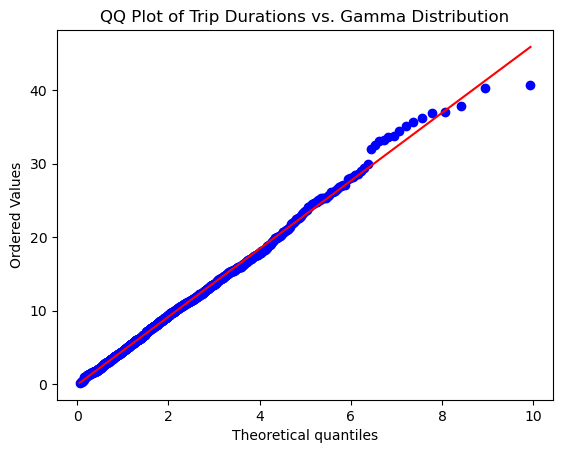

In [25]:
# K-S test for Gamma
ks_statistic, p_value = kstest(trip_durations, 'gamma', args=params_gamma)

print(f"K-S Statistic (Gamma): {ks_statistic}")
print(f"P-Value: {p_value}")

# QQ Plot
import scipy.stats as stats

stats.probplot(trip_durations, dist="gamma", sparams=(params_gamma[0],), plot=plt)
plt.title('QQ Plot of Trip Durations vs. Gamma Distribution')
plt.show()

K-S Statistic (Normal): 0.91884317007884
P-Value: 0.0


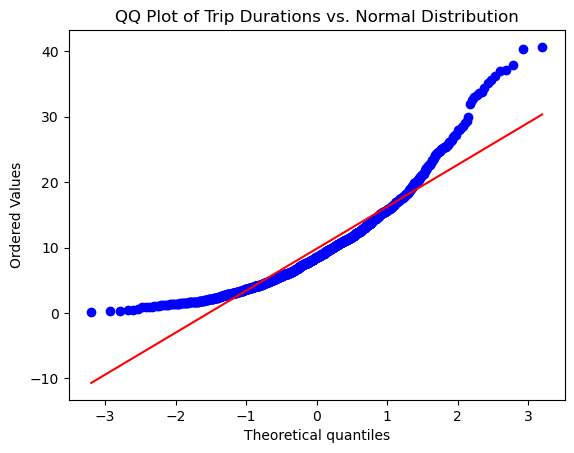

In [26]:
# K-S test for Normal distribution
ks_statistic, p_value = stats.kstest(trip_durations, 'norm')

print(f"K-S Statistic (Normal): {ks_statistic}")
print(f"P-Value: {p_value}")

# QQ Plot for Normal distribution
stats.probplot(trip_durations, dist="norm", plot=plt)
plt.title('QQ Plot of Trip Durations vs. Normal Distribution')
plt.show()

## Chapter 1: Distributions in the City

<!-- Introduction to the Chapter -->
## 1.1 Understanding Statistical Distributions

### Introduction

In urban data science, statistical distributions are fundamental tools for understanding and modeling the variability inherent in city-related data. Whether we're analyzing the number of taxi rides in New York City on a given day, the distribution of building heights, or the frequency of subway arrivals, statistical distributions help us make sense of complex urban phenomena.

This chapter introduces the concept of statistical distributions, explores their key characteristics through distribution moments, and provides guidance on identifying the appropriate distribution for a given dataset. We will use examples from New York City to illustrate these concepts, along with Python code to demonstrate practical applications.

<!-- What is a Statistical Distribution Section -->
### 1.1.1 What Is a Statistical Distribution?

A statistical distribution describes how values of a variable are distributed. It provides a function that shows the possible values for a variable and how often they occur. Understanding the underlying distribution of data is crucial for:

- **Modeling and Prediction**: Choosing the right distribution improves the accuracy of models.
- **Hypothesis Testing**: Many statistical tests assume specific distributions.
- **Risk Assessment**: Knowing the distribution helps in estimating probabilities of extreme events.

In urban contexts, distributions help us answer questions like:

- What is the probability that a taxi will have more than 10 rides in an hour?
- How likely is it for a building to exceed a certain height?
- What is the expected number of emergency calls during peak hours?

<!-- Distribution Moments Section -->
### 1.1.2 Distribution Moments: The Building Blocks

Distribution moments are quantitative measures that capture key characteristics of a distribution. The most commonly used moments are:

1. **Mean (First Moment)**: Measures the central tendency.
2. **Variance (Second Moment)**: Measures the dispersion or spread.
3. **Skewness (Third Moment)**: Measures the asymmetry.
4. **Kurtosis (Fourth Moment)**: Measures the "tailedness" or peak sharpness.

Understanding these moments provides insights into the data's behavior and aids in selecting appropriate statistical models.

#### Mean

The mean is the average value of the dataset.

$$
\mu = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

#### Variance

Variance quantifies how much the values deviate from the mean.

$$
\sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2
$$

#### Skewness

Skewness indicates the degree of asymmetry.

- **Positive Skew**: Tail on the right side.
- **Negative Skew**: Tail on the left side.

#### Kurtosis

Kurtosis measures the heaviness of the tails.

- **Leptokurtic**: Heavy tails (positive kurtosis).
- **Platykurtic**: Light tails (negative kurtosis).
- **Mesokurtic**: Normal tails (zero kurtosis, as in the normal distribution).

<!-- Common Distributions Section -->
### 1.1.3 Common Distributions in Urban Data

Urban phenomena often follow specific statistical distributions. Here we present common distributions in an order that progresses from discrete to continuous, and from simple to more complex distributions.

<!-- Poisson Distribution -->
#### Poisson Distribution

**Type**: Discrete

**Use Case**: Modeling the number of times an event occurs in a fixed interval of time or space.

**Example**: Number of emergency calls received by NYC's 911 system per hour.

The probability mass function (PMF) is:

$$
P(k; \lambda) = \frac{e^{-\lambda} \lambda^k}{k!}
$$

where:

- \( \lambda \) is the average rate (mean number of occurrences in the interval).
- \( k \) is the actual number of occurrences.

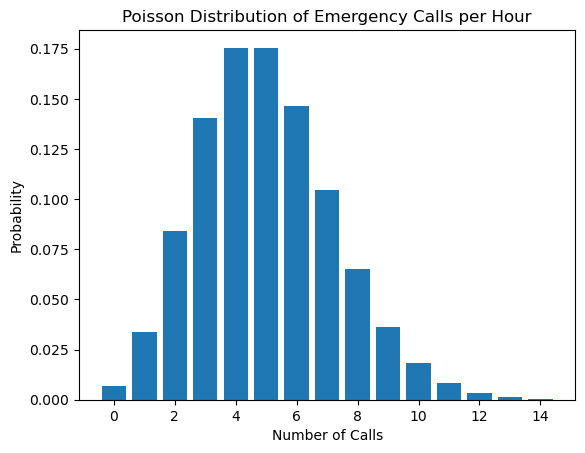

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Average number of emergency calls per hour
lambda_rate = 5

# Possible number of calls
k = np.arange(0, 15)

# PMF
pmf = poisson.pmf(k, lambda_rate)

plt.bar(k, pmf)
plt.title('Poisson Distribution of Emergency Calls per Hour')
plt.xlabel('Number of Calls')
plt.ylabel('Probability')
plt.show()

<!-- Binomial Distribution -->
#### Binomial Distribution

**Type**: Discrete

**Use Case**: Modeling the number of successes in a fixed number of independent Bernoulli trials.

**Example**: Number of commuters who choose to take the subway out of a random sample of people.

The probability mass function is:

$$
P(k; n, p) = \binom{n}{k} p^k (1 - p)^{n - k}
$$

where:

- \( n \) is the number of trials.
- \( k \) is the number of successes.
- \( p \) is the probability of success on a single trial.

In [1]:
"Poisson, simple exponential, stretched exponential, and power law distributions. The remaining distributions in Table 4.2 are occasionally used to fit the degrees of some networks, despite the fact that we lack theoretical basis for their relevance for networks."
- Barabasi, Ch.4 on network science related distributions

SyntaxError: invalid syntax (401232129.py, line 2)

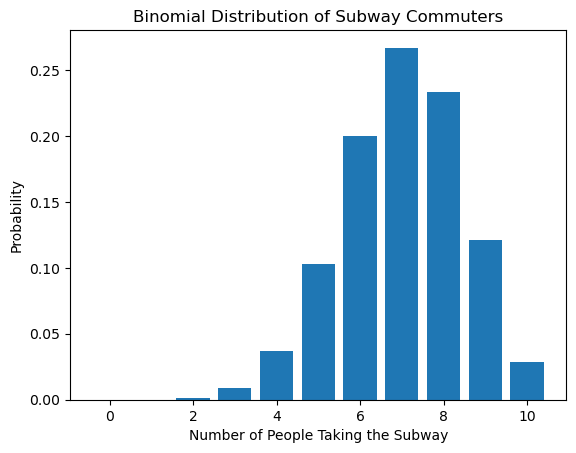

In [28]:
from scipy.stats import binom

# Number of trials (sample size)
n = 10
# Probability of success (taking the subway)
p = 0.7

# Possible number of successes
k = np.arange(0, n + 1)

# PMF
pmf = binom.pmf(k, n, p)

plt.bar(k, pmf)
plt.title('Binomial Distribution of Subway Commuters')
plt.xlabel('Number of People Taking the Subway')
plt.ylabel('Probability')
plt.show()

# Distributions

*Well, it's up in the mornin' tryin' to find a job of work<br>
Stand in one place till your feet begin to hurt<br>
If you got a lot o' money you can make yourself a'merry<br>
If you only got a nickel, it's the Staten Island Ferry*<br>
\- Bob Dylan, *[Hard Times in New York Town](https://www.youtube.com/watch?v=QbmWcHW8xR4)*

Welcome to New York! We'll begin our journey by getting to know one of the world's great global cities through the lens of statistics, starting with a survey of statistical distributions.

## What Do Distributions Tell Us About Cities?

Cities are symphonies of interaction - people stride through streets, businesses open and close, neighbors gossip, strangers meet on a first date, delivery vehicles weave through alleys, and somewhere, always, a toilet flushes. At first glance, these urban phenomena might appear to be chaotic, defying systemic analysis. Yet beneath the apparent cacophony often lies remarkable regularity that we can attempt to understand through the mathematical framework of statistics.

At its core, a statistical distribution represents our understanding of how values vary across a population. They allow us to describe and understand our data in a systematic way, and form the basis of many of the predictive methods we'll tackle later.

*What fraction of buildings in Manhattan exceed 20 stories? How long do people wait for buses in Queens? How much can I hope to earn next year if I open a coffee shop in Bed Stuy?* Questions like these are fundamental to the understanding of urban life, and find their answers in the shapes and patterns of statistical distributions.

<div style="margin-left: 40px; font-style: italic;">
<sup>*</sup>"All models are wrong, but some are useful" - George Box, British Statistician
</div>

Alas, data rarely come pre-packaged with labels stating "*I am a Gamma Distribution.*" In the real world, data are often messy, raw and discordant. Indeed, it can be convincingly argued that probability distributions [don't even exist](https://www.nature.com/articles/d41586-024-04096-5)! (Although it can't be convincingly argued that they aren't useful!<sup>*</sup>)

The act of matching data with a distribution tells us something fundamental about how the data originate. When we discover that wait times at intersection crossings follow an exponential distribution, we're uncovering more than a pattern - we're revealing the underlying mechanics of urban movement, helping build a framework that helps us understand why these patterns emerge and how they might change under different conditions. This knowledge becomes invaluable for urban planning, policy-making, and the design of more livable cities.

The distribution of new building heights, for example, likely reflect a dialog between engineering constraints, economic forces, and government regulation. Changes to any of these dimensions - say the development of reliable [carbon fibre reinforced concrete](https://www.dezeen.com/2021/07/30/henn-tu-dresden-carbon-fibre-concrete-building/) or [to building fire codes](https://www.treehugger.com/single-stair-buildings-united-states-5197036) - could have a notable impact on the distribution of new building heights.

Normal distributions often emerge from the cumulative effect of many independent, small influences, while power law distributions typically arise in systems shaped by preferential attachment or disproportionate reinforcement of advantage (aka "winner take all" scenarios).

<div style="margin-left: 40px; font-style: italic;">
<sup>*</sup> Seemingly unrelated systems, such as vascular & transport networks display remarkable similarities, as we'll explore in Chapter 5.
</div>

What makes distributions particularly powerful is their universality. Similar patterns often emerge across different cities and cultures<sup>*</sup>, suggesting fundamental principles underlying urban organization. A distribution of retail store sizes in New York might mirror one in Tokyo, hinting at common economic principles at work. Yet the parameters of these distributions – their precise shapes and values – can reveal crucial differences between cities, neighborhoods, or time periods.

## A Tour of Common Distributions

Many statistics texts start with descriptive statistics (mean, standard deviation, etc.) before working up to distributions. While this may suit some introductory courses, I find it unintuitive. Descriptive statistics are important simplifications, but understanding when they're appropriate and what they're simplifying is critical, and something that I see this mistaken all too often in practice. Given most readers will know what a "mean" is, I feel strongly that starting with distributions is a more appropriate approach here.

Most statistics books also clearly divide "discrete" & "continuous" distributions. While we'll address these differences in various contexts, given the generally large-scale of data used in modern data science, this is not a fundamental distinction for most practical purposes.

The best way to build intuition is to see examples and practice. Below, I've outlined a handful of statistical distributions that I believe an Urban Data Scientist should have some working familiarity with. I particularly focus on *why* these distributions emerge -- they are not simply formulae to memorize, but clues that point us towards a deeper understanding of the underlying process. If we're a little clever, this can help us not only predict future values, but allow us to imagine, foster, and engineer better urban systems.

We'll start with an overview of the distributions themselves, looking at an example or two for each. We'll then dive into how to evaluate whether our data match a given distribution. Loosely speaking, when we're dealing with known, idealized distributions, we call this "Probability"; when we're evaluating how to fit messy, real-world data to an idealized pattern and understanding the uncertainty involved in this fitting, this is called "Statistics."

What follows can, admittedly, be a bit dense. It's not meant to be fully digested in one sitting; rather, try to pull away the key points and develop a brief intuition about each distribution - look for the *why*. Then go out in the world, observe various phenomena, and try to see if you can identify the associated distribution.

### Uniform Distributions

<div style="margin-left: 40px; font-style: italic;">
<sup>*</sup> If you want to annoy your friends, next time you're asked to pick a random number between 1 and 100, ask them which distribution they'd like you to sample from.
</div>

The Uniform Distribution is the most basic of distributions; it is often what is colloquially meant when someone says "random<sup>*</sup>." It assumes that all values between two end points are equally likely. 

Despite this colloquial association with 'randomness,' uniform distributions are remarkably uncommon in the real world. Uniformity typically appears only when humans deliberately impose it through design or regulation.

When we encounter uniform distributions in cities, they often tell us something about human intervention - about our attempts to impose order on urban chaos, whether through zoning laws, transit scheduling, or urban planning guidelines.

#### Mathematical Foundations & Assumptions
The Uniform distribution describes a variable equally likely to take any value within an interval $[a,b]$. It's defined by just two parameters:

$a$: minimum value<br>
$b$: maximum value

And has a probability density function (PDF) of:

$$
f(x) =
\begin{cases} 
\frac{1}{b-a} & \text{if } x \in [a,b], \\
0 & \text{otherwise}.
\end{cases}
$$

Key assumptions:
* Constant probability density throughout the interval
* Zero probability outside the interval
* All intervals of equal length have equal probability

#### In Urban Systems
Uniform distributions appear in urban contexts primarily where human design imposes regularity. Examples include:

```python
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

# Setting the aesthetic style for plots
plt.style.use('dark_background')
```

##### Example: Bus Arrival Times in Idealized Schedules

In an idealized system where buses are scheduled to arrive exactly every 15 minutes, the waiting time for a passenger arriving randomly would follow a uniform distribution between 0 and 15 minutes:

```python
# Generate random arrival times (in minutes) from a uniform distribution
np.random.seed(42)  # For reproducibility
wait_times = np.random.uniform(0, 15, 1000)

# Create a plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(wait_times, bins=20, kde=True, color="#D1B675", alpha=0.7, ax=ax)
ax.set_title('Passenger Wait Times for Buses With Perfect 15-Minute Intervals')
ax.set_xlabel('Wait Time (minutes)')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)
```

In reality, due to traffic, weather, and other factors, bus arrivals rarely follow a perfect uniform distribution - we'll see more realistic models later.

##### Example: Block Lengths on Manhattan's Grid System

Manhattan's street grid, established by the Commissioners' Plan of 1811, created a remarkably uniform system of block lengths between avenues:

```python
# Let's simulate a walk down 5th Avenue, measuring the distance between streets
# Standard Manhattan blocks are about 264 feet between streets
# But we'll add small variations to account for real-world imperfections

block_lengths = np.random.uniform(250, 278, 30)  # 30 blocks with slight variation
street_numbers = np.arange(1, 31)

# Plot the block lengths
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(street_numbers, block_lengths, color="#93C5FD", alpha=0.8)
ax.set_title('Block Lengths on 5th Avenue (1st-30th Streets)')
ax.set_xlabel('Street Number')
ax.set_ylabel('Block Length (feet)')
ax.set_ylim(0, 300)
ax.grid(True, alpha=0.3)
```

The uniform distribution is a starting point for understanding more complex distributions that we'll explore next.

### Normal Distributions

The Normal (or Gaussian) distribution is perhaps the most famous probability distribution, characterized by its symmetrical, bell-shaped curve. It emerges naturally in phenomena influenced by many small, independent random factors.

#### Mathematical Foundations & Assumptions

The Normal distribution is defined by two parameters:
- $\mu$ (mu): The mean, which defines the center of the distribution
- $\sigma$ (sigma): The standard deviation, which defines the spread

Its probability density function is:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

Key assumptions:
* The variable is influenced by many small, independent random factors
* No single factor dominates the outcome
* The mean and variance are finite and well-defined

#### In Urban Systems

Normal distributions appear throughout urban systems, especially in variables that result from many small, independent influences:

##### Example: Building Heights in Midtown Manhattan

Building heights in established districts often approximate a normal distribution, reflecting a balance of economic, regulatory, and physical constraints:

```python
# Generate simulated building heights for Midtown Manhattan
np.random.seed(42)
# Mean of about 40 stories with standard deviation of 15
building_heights = np.random.normal(40, 15, 200)
# Adjust to make sure no buildings have negative heights
building_heights = np.clip(building_heights, 1, None)

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(building_heights, bins=20, kde=True, color="#B91C1C", alpha=0.7, ax=ax)
ax.set_title('Distribution of Building Heights in Midtown Manhattan')
ax.set_xlabel('Building Height (stories)')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)

# Overlay the theoretical normal distribution
x = np.linspace(0, 100, 100)
y = stats.norm.pdf(x, 40, 15) * len(building_heights) * (100/20)  # Scale to match histogram
ax.plot(x, y, 'r--', linewidth=2, color="#C3FF5B")
ax.legend(['Theoretical Normal', 'Observed Heights'])
```

##### Example: Commute Times in Brooklyn

Commute times often follow a normal distribution due to the many small factors that influence trip duration:

```python
# Generate simulated commute times from Brooklyn to Manhattan
np.random.seed(123)
commute_times = np.random.normal(45, 12, 500)  # Mean 45 minutes, SD 12 minutes

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(commute_times, bins=20, kde=True, color="#8BE9FD", alpha=0.7, ax=ax)
ax.set_title('Brooklyn to Manhattan Commute Times')
ax.set_xlabel('Commute Time (minutes)')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)
```

While many urban variables appear normally distributed at first glance, closer inspection often reveals skewness or fat tails that better fit other distributions - which brings us to our next section.

### Exponential Distributions

The exponential distribution models the time between independent events that occur at a constant average rate. It's characterized by a rapid initial decline followed by a long tail.

#### Mathematical Foundations & Assumptions

The exponential distribution has a single parameter:
- $\lambda$ (lambda): The rate parameter

Its probability density function is:

$$f(x) = \lambda e^{-\lambda x} \text{ for } x \geq 0$$

Key assumptions:
* Events occur continuously and independently
* The rate at which events occur is constant over time
* The "memoryless" property: The future waiting time is independent of how long you've already waited

#### In Urban Systems

Exponential distributions appear frequently in urban systems when modeling waiting times and intervals between random events:

##### Example: Taxi Pickup Wait Times in Manhattan

The waiting time for a taxi in busy areas of Manhattan often follows an exponential distribution:

```python
# Generate simulated taxi wait times (in minutes)
np.random.seed(42)
taxi_wait_times = np.random.exponential(scale=3, size=1000)  # Mean wait time of 3 minutes

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(taxi_wait_times, bins=30, kde=True, color="#FF88FF", alpha=0.7, ax=ax)
ax.set_title('Wait Times for Taxi Pickups in Midtown Manhattan')
ax.set_xlabel('Wait Time (minutes)')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 15)  # Limit x-axis to focus on most common wait times
ax.grid(True, alpha=0.3)
```

##### Example: Time Between Subway Train Arrivals

Particularly during off-peak hours when headways are longer, the time between train arrivals often follows an exponential distribution due to the randomness in arrival patterns:

```python
# Generate simulated times between train arrivals (in minutes)
np.random.seed(123)
train_intervals = np.random.exponential(scale=8, size=500)  # Mean interval of 8 minutes

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(train_intervals, bins=25, kde=True, color="#D1B675", alpha=0.7, ax=ax)
ax.set_title('Time Between Subway Train Arrivals (Off-Peak Hours)')
ax.set_xlabel('Time Interval (minutes)')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 30)
ax.grid(True, alpha=0.3)
```

The exponential distribution's memoryless property is particularly relevant in urban systems - a passenger who has been waiting for 10 minutes for a subway train is no more likely to see one arrive in the next minute than a passenger who just arrived at the platform (assuming true randomness).

### Power Law Distributions

Power law distributions are characterized by a "heavy tail" where extreme values occur with higher probability than in a normal distribution. They're often associated with scale-free networks, preferential attachment, and "winner-take-all" phenomena.

#### Mathematical Foundations & Assumptions

A power law distribution has the form:

$$f(x) \propto x^{-\alpha}$$

Where $\alpha$ is the scaling parameter (typically greater than 1).

Key characteristics:
* No characteristic scale (scale-free)
* Self-similarity across scales
* Extreme events are rare but significant ("black swans")
* Often plotted on log-log scales where they appear as straight lines

#### In Urban Systems

Power laws are ubiquitous in urban systems, particularly in size distributions, economic measures, and network structures:

##### Example: Population Distribution Across NYC Neighborhoods

The distribution of population across neighborhoods often follows a power law, with a few densely populated areas and many less dense ones:

```python
# Generate simulated population data for NYC neighborhoods
np.random.seed(42)
# Using Pareto distribution to generate power-law distributed data
alpha = 1.5  # Shape parameter for Pareto distribution
neighborhood_populations = (np.random.pareto(alpha, 60) + 1) * 5000

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(neighborhood_populations, bins=30, kde=False, color="#93C5FD", alpha=0.7, ax=ax)
ax.set_title('Population Distribution Across NYC Neighborhoods')
ax.set_xlabel('Neighborhood Population')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)

# Create a log-log plot to show the power law relationship
fig, ax = plt.subplots(figsize=(8, 5))
sorted_pop = np.sort(neighborhood_populations)[::-1]  # Sort in descending order
rank = np.arange(1, len(sorted_pop) + 1)
ax.loglog(rank, sorted_pop, 'o', color="#C3FF5B", alpha=0.7)
ax.set_title('Rank-Size Plot of NYC Neighborhood Populations (Log-Log Scale)')
ax.set_xlabel('Rank')
ax.set_ylabel('Population')
ax.grid(True, alpha=0.3, which="both")
```

##### Example: Business Size Distribution in NYC

The distribution of business sizes (by number of employees or revenue) typically follows a power law, with many small businesses and a few very large ones:

```python
# Generate simulated business size data (number of employees)
np.random.seed(456)
alpha = 1.3
business_sizes = (np.random.pareto(alpha, 1000) + 1) * 5  # At least 5 employees

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
counts, bins, _ = ax.hist(business_sizes, bins=50, color="#FFD700", alpha=0.7)
ax.set_title('Distribution of Business Sizes in NYC')
ax.set_xlabel('Number of Employees')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 500)  # Focus on the more common business sizes
ax.grid(True, alpha=0.3)

# Log-log plot to show power law
fig, ax = plt.subplots(figsize=(8, 5))
# Use log bins for better visualization
log_bins = np.logspace(np.log10(min(business_sizes)), np.log10(max(business_sizes)), 20)
counts, bins, _ = ax.hist(business_sizes, bins=log_bins, color="#B91C1C", alpha=0.7)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Business Size Distribution (Log-Log Scale)')
ax.set_xlabel('Number of Employees (Log Scale)')
ax.set_ylabel('Frequency (Log Scale)')
ax.grid(True, alpha=0.3, which="both")
```

The prevalence of power laws in urban systems suggests that self-organization, preferential attachment, and feedback mechanisms are fundamental to how cities grow and organize themselves.

### Lognormal Distributions

Lognormal distributions occur when the logarithm of a variable follows a normal distribution. They are common in many growth processes and economic variables.

#### Mathematical Foundations & Assumptions

A lognormal distribution is defined by two parameters:
- $\mu$: The mean of the variable's natural logarithm
- $\sigma$: The standard deviation of the variable's natural logarithm

Its probability density function is:

$$f(x) = \frac{1}{x\sigma\sqrt{2\pi}}e^{-\frac{(\ln(x)-\mu)^2}{2\sigma^2}} \text{ for } x > 0$$

Key characteristics:
* Always positive values
* Right-skewed (long tail to the right)
* Multiplicative processes often lead to lognormal distributions

#### In Urban Systems

Lognormal distributions frequently appear in urban economics and real estate:

##### Example: Housing Prices in New York City

Real estate prices tend to follow a lognormal distribution, with many moderately priced properties and a long tail of high-value properties:

```python
# Generate simulated housing prices for NYC
np.random.seed(42)
# Parameters chosen to represent NYC's housing market
mu, sigma = np.log(800000), 0.7  # Parameters for the underlying normal distribution
housing_prices = np.random.lognormal(mean=mu, sigma=sigma, size=1000)

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(housing_prices/1000000, bins=40, kde=True, color="#8BE9FD", alpha=0.7, ax=ax)
ax.set_title('Distribution of Housing Prices in NYC')
ax.set_xlabel('Price ($ millions)')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 5)  # Focus on the more common price range
ax.grid(True, alpha=0.3)

# Also plot the distribution of log-transformed prices to show the underlying normality
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(np.log(housing_prices), bins=30, kde=True, color="#D1B675", alpha=0.7, ax=ax)
ax.set_title('Distribution of Log-Transformed Housing Prices')
ax.set_xlabel('Log(Price)')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)
```

##### Example: Income Distribution in NYC Neighborhoods

Income distributions frequently follow a lognormal pattern:

```python
# Generate simulated income data
np.random.seed(123)
mu, sigma = np.log(75000), 0.65  # Parameters for log-normal distribution
incomes = np.random.lognormal(mean=mu, sigma=sigma, size=2000)

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(incomes/1000, bins=50, kde=True, color="#FF88FF", alpha=0.7, ax=ax)
ax.set_title('Income Distribution in NYC')
ax.set_xlabel('Annual Income ($ thousands)')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 300)  # Focus on the more common income range
ax.grid(True, alpha=0.3)
```

The lognormal distribution often competes with the power law as a model for income and wealth distributions, with hybrid models sometimes providing the best fit.

### Poisson Distributions

The Poisson distribution models the number of events occurring within a fixed interval of time or space, assuming these events happen at a constant average rate independently of each other.

#### Mathematical Foundations & Assumptions

The Poisson distribution has a single parameter:
- $\lambda$ (lambda): The average number of events per interval

Its probability mass function is:

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!} \text{ for } k = 0, 1, 2, \ldots$$

Key assumptions:
* Events occur independently
* The average rate of occurrence is constant
* Two events cannot occur at exactly the same time
* The probability of an event in a small interval is proportional to the length of the interval

#### In Urban Systems

Poisson distributions model many counting processes in urban environments:

##### Example: Traffic Accidents per Day in NYC

The number of traffic accidents per day in a particular district often follows a Poisson distribution:

```python
# Generate simulated daily traffic accident counts
np.random.seed(42)
lambda_accidents = 12  # Average of 12 accidents per day
days = 365
accident_counts = np.random.poisson(lambda_accidents, days)

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
counts, bins, _ = ax.hist(accident_counts, bins=range(0, max(accident_counts)+2), 
                         color="#B91C1C", alpha=0.7, density=True)
ax.set_title('Daily Traffic Accidents in NYC District')
ax.set_xlabel('Number of Accidents')
ax.set_ylabel('Probability')
ax.grid(True, alpha=0.3)

# Overlay the theoretical Poisson PMF
x = np.arange(0, 25)
pmf = stats.poisson.pmf(x, lambda_accidents)
ax.plot(x, pmf, 'o-', color="#93C5FD", alpha=0.7, markersize=8)
ax.legend(['Theoretical Poisson', 'Observed Frequency'])
```

##### Example: Customer Arrivals at a Busy Cafe in SoHo

The number of customers arriving at a cafe per hour often follows a Poisson distribution:

```python
# Generate simulated hourly customer arrivals
np.random.seed(123)
lambda_customers = 25  # Average of 25 customers per hour
hours = 100
customer_arrivals = np.random.poisson(lambda_customers, hours)

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
counts, bins, _ = ax.hist(customer_arrivals, bins=range(0, max(customer_arrivals)+2), 
                         color="#C3FF5B", alpha=0.7, density=True)
ax.set_title('Hourly Customer Arrivals at SoHo Cafe')
ax.set_xlabel('Number of Customers')
ax.set_ylabel('Probability')
ax.grid(True, alpha=0.3)

# Overlay the theoretical Poisson PMF
x = np.arange(0, 50)
pmf = stats.poisson.pmf(x, lambda_customers)
ax.plot(x, pmf, 'o-', color="#D1B675", alpha=0.7, markersize=8)
ax.legend(['Theoretical Poisson', 'Observed Frequency'])
```

The Poisson distribution is closely related to the exponential distribution: if events occur according to a Poisson process, the time between consecutive events follows an exponential distribution.

## Testing for Distribution Fit

When working with real urban data, a critical step is determining which statistical distribution best describes our observations. This process involves both visual methods and formal statistical tests.

### Visual Methods

#### Histograms and Density Plots

The simplest approach is to plot the data and visually compare it to theoretical distributions:

```python
# Generate some real-world-like data that's a mix of distributions
np.random.seed(42)
# Mix of normal and lognormal to represent something like building ages in a neighborhood
building_ages = np.concatenate([
    np.random.normal(80, 15, 200),  # Older buildings from one era
    np.random.lognormal(mean=3.5, sigma=0.4, size=300)  # Newer buildings with long tail
])

# Plot histogram with density overlays of different distributions
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(building_ages, bins=30, kde=False, color="#93C5FD", alpha=0.5, ax=ax)

# Generate x values for plotting theoretical distributions
x = np.linspace(0, 200, 1000)

# Fit and plot normal distribution
norm_params = stats.norm.fit(building_ages)
norm_pdf = stats.norm.pdf(x, *norm_params)
ax.plot(x, norm_pdf * len(building_ages) * (200/30), 'r-', label='Normal Fit', linewidth=2, color="#FF88FF")

# Fit and plot lognormal distribution
lognorm_params = stats.lognorm.fit(building_ages)
lognorm_pdf = stats.lognorm.pdf(x, *lognorm_params)
ax.plot(x, lognorm_pdf * len(building_ages) * (200/30), 'g-', label='Lognormal Fit', linewidth=2, color="#C3FF5B")

ax.set_title('Distribution of Building Ages with Theoretical Fits')
ax.set_xlabel('Building Age (years)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)
```

#### Q-Q Plots

Quantile-Quantile (Q-Q) plots are powerful tools for comparing your data to a theoretical distribution. If the points approximately follow a straight line, the data fits the distribution:

```python
# Create Q-Q plots for the building age data against different distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normal Q-Q plot
stats.probplot(building_ages, dist="norm", plot=axes[0])
axes[0].set_title('Normal Q-Q Plot of Building Ages')
axes[0].grid(True, alpha=0.3)

# Lognormal Q-Q plot
stats.probplot(np.log(building_ages), dist="norm", plot=axes[1])
axes[1].set_title('Lognormal Q-Q Plot of Building Ages')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
```

### Statistical Tests

Visual methods are subjective, so we often use formal statistical tests to evaluate goodness-of-fit:

#### Kolmogorov-Smirnov Test

The K-S test compares your data to a reference distribution by measuring the maximum distance between their cumulative distribution functions:

```python
# Perform K-S tests against different distributions
# Normal distribution
ks_normal = stats.kstest(building_ages, 'norm', args=norm_params)

# Lognormal distribution
ks_lognormal = stats.kstest(building_ages, 'lognorm', args=lognorm_params)

print(f"K-S Test for Normal Distribution: statistic={ks_normal.statistic:.4f}, p-value={ks_normal.pvalue:.4e}")
print(f"K-S Test for Lognormal Distribution: statistic={ks_lognormal.statistic:.4f}, p-value={ks_lognormal.pvalue:.4e}")
```

#### Chi-Square Test

The Chi-Square test compares the observed frequency distribution with the expected frequency distribution:

```python
# Perform Chi-Square test
# First, bin the data
hist, bin_edges = np.histogram(building_ages, bins=20, density=False)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2

# Expected frequencies for normal distribution
expected_norm = stats.norm.pdf(bin_centers, *norm_params) * len(building_ages) * (bin_edges[1] - bin_edges[0])
chi2_norm = stats.chisquare(hist, expected_norm)

# Expected frequencies for lognormal distribution
expected_lognorm = stats.lognorm.pdf(bin_centers, *lognorm_params) * len(building_ages) * (bin_edges[1] - bin_edges[0])
chi2_lognorm = stats.chisquare(hist, expected_lognorm)

print(f"Chi-Square Test for Normal Distribution: statistic={chi2_norm.statistic:.4f}, p-value={chi2_norm.pvalue:.4e}")
print(f"Chi-Square Test for Lognormal Distribution: statistic={chi2_lognorm.statistic:.4f}, p-value={chi2_lognorm.pvalue:.4e}")
```

#### Information Criteria

For more complex model selection, we can use criteria like AIC (Akaike Information Criterion) or BIC (Bayesian Information Criterion):

```python
from scipy.stats import norm, lognorm, expon, gamma
from scipy import optimize

# Define functions to calculate AIC and BIC
def calc_aic(log_likelihood, k):
    """Calculate AIC where k is the number of parameters"""
    return 2 * k - 2 * log_likelihood

def calc_bic(log_likelihood, k, n):
    """Calculate BIC where k is the number of parameters and n is sample size"""
    return k * np.log(n) - 2 * log_likelihood

# Define negative log-likelihood functions for each distribution
def neg_ll_norm(params, data):
    mu, sigma = params
    return -np.sum(norm.logpdf(data, loc=mu, scale=sigma))

def neg_ll_lognorm(params, data):
    s, loc, scale = params
    return -np.sum(lognorm.logpdf(data, s=s, loc=loc, scale=scale))

# Fit models by minimizing negative log-likelihood
norm_result = optimize.minimize(neg_ll_norm, x0=[np.mean(building_ages), np.std(building_ages)], args=(building_ages,))
lognorm_result = optimize.minimize(neg_ll_lognorm, x0=[1, 0, np.mean(building_ages)], args=(building_ages,))

# Calculate AIC and BIC
n = len(building_ages)
aic_norm = calc_aic(-norm_result.fun, k=2)
bic_norm = calc_bic(-norm_result.fun, k=2, n=n)
aic_lognorm = calc_aic(-lognorm_result.fun, k=3)
bic_lognorm = calc_bic(-lognorm_result.fun, k=3, n=n)

print(f"Normal distribution: AIC={aic_norm:.2f}, BIC={bic_norm:.2f}")
print(f"Lognormal distribution: AIC={aic_lognorm:.2f}, BIC={bic_lognorm:.2f}")
```

By combining visual methods with statistical tests, we can confidently determine which distribution best describes our urban data.

## Case Studies: Distributions in New York City

Let's apply our understanding of distributions to real-world examples from New York City.

### Case Study 1: Subway Ridership Across Stations

The distribution of daily subway ridership across stations in NYC shows striking patterns:

```python
# Simulate NYC subway station daily ridership data
np.random.seed(42)
# Create a power-law-like distribution with some randomness
n_stations = 472  # Actual number of NYC subway stations
base_ridership = np.sort((np.random.pareto(1.5, n_stations) + 1) * 5000)[::-1]

# Add day-to-day variation
days = 30
daily_ridership = np.zeros((n_stations, days))
for i in range(days):
    # Add random daily fluctuation of ±20%
    daily_ridership[:, i] = base_ridership * np.random.uniform(0.8, 1.2, n_stations)

# Calculate average daily ridership per station
avg_ridership = np.mean(daily_ridership, axis=1)

# Plot the distribution on a log-log scale
fig, ax = plt.subplots(figsize=(10, 6))
ranks = np.arange(1, len(avg_ridership) + 1)
ax.loglog(ranks, avg_ridership, 'o', color="#B91C1C", alpha=0.5)
ax.set_title('NYC Subway Station Ridership Distribution (Log-Log Scale)')
ax.set_xlabel('Station Rank')
ax.set_ylabel('Average Daily Ridership')
ax.grid(True, alpha=0.3, which="both")

# Fit a power law
def power_law(x, a, b):
    return a * x**(-b)

from scipy.optimize import curve_fit
popt, _ = curve_fit(power_law, ranks, avg_ridership)
xfit = np.linspace(1, n_stations, 100)
yfit = power_law(xfit, *popt)
ax.loglog(xfit, yfit, '-', color="#FFD700", linewidth=2)
ax.legend([f'Subway Stations', f'Power Law Fit (exponent: {popt[1]:.2f})'])
```

This power law distribution reveals a "rich-get-richer" dynamic, where a small number of central stations handle a disproportionate share of riders. The pattern follows Zipf's law, a special case of power law distributions where the frequency of an item is inversely proportional to its rank.

### Case Study 2: Restaurant Health Inspection Scores

Health inspection scores for NYC restaurants provide an interesting case study in distributions:

```python
# Simulate NYC restaurant health inspection scores
np.random.seed(123)
# Most restaurants pass but with different scores, with a tail of poor performers
n_restaurants = 1000
# Generate scores roughly centered around 85 with a left skew (more poor performers than excellent ones)
inspection_scores = np.round(100 - np.random.lognormal(mean=2.3, sigma=0.6, size=n_restaurants))
# Clip to valid range (0-100)
inspection_scores = np.clip(inspection_scores, 0, 100)

# Plot the distribution
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(inspection_scores, bins=range(0, 105, 5), kde=False, color="#8BE9FD", alpha=0.7, ax=ax)
ax.set_title('Distribution of Restaurant Health Inspection Scores in NYC')
ax.set_xlabel('Inspection Score')
ax.set_ylabel('Number of Restaurants')
ax.set_xticks(range(0, 105, 10))
ax.grid(True, alpha=0.3)

# Fit and overlay a normal distribution
norm_params = stats.norm.fit(inspection_scores)
x = np.linspace(0, 100, 1000)
norm_pdf = stats.norm.pdf(x, *norm_params)
ax.plot(x, norm_pdf * len(inspection_scores) * 5, 'r-', linewidth=2, color="#FF88FF")
ax.legend(['Normal Fit', 'Observed Scores'])
```

The distribution is left-skewed, with a concentration of restaurants achieving passing scores but a long tail of poor performers. This is typical of regulatory compliance scenarios, where most businesses meet standards but a minority struggle with consistent compliance.

### Case Study 3: Real Estate Property Values in Different Boroughs

Property values across NYC's boroughs show distinctive distributional patterns:

```python
# Simulate property values across NYC boroughs
np.random.seed(42)
# Define parameters for different boroughs (means in $1000s)
borough_params = {
    'Manhattan': (2000, 0.7),  # (mean, sigma) for lognormal
    'Brooklyn': (1200, 0.6),
    'Queens': (800, 0.5),
    'Bronx': (500, 0.4),
    'Staten Island': (700, 0.3)
}

# Generate property values
property_values = {}
n_properties = 500
for borough, (mean, sigma) in borough_params.items():
    # Use lognormal distribution for property values
    mu = np.log(mean) - 0.5 * sigma**2  # Adjustment to make the actual mean match the target
    property_values[borough] = np.random.lognormal(mean=mu, sigma=sigma, size=n_properties)

# Plot distributions for each borough
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#D1B675', '#93C5FD', '#B91C1C', '#C3FF5B', '#FF88FF']
for i, (borough, values) in enumerate(property_values.items()):
    sns.kdeplot(values/1000, ax=ax, label=borough, color=colors[i % len(colors)], linewidth=2)

ax.set_title('Distribution of Property Values Across NYC Boroughs')
ax.set_xlabel('Property Value ($ millions)')
ax.set_ylabel('Density')
ax.set_xlim(0, 5)  # Focus on the more common price range
ax.legend()
ax.grid(True, alpha=0.3)
```

These lognormal distributions highlight the significant disparities in property values across boroughs. Manhattan's distribution has the highest mean and the fattest tail, indicating both higher average prices and more extreme high-value properties.

## Applications in Urban Planning and Policy

Understanding distributions in urban data has profound implications for planning and policy. Let's explore a few examples.

### Optimizing Public Transit Routes

Using our knowledge of population and commute distributions, we can optimize transit routes:

```python
# Simulate population density along a potential transit corridor
np.random.seed(42)
# Distance along corridor (in miles)
distance = np.linspace(0, 10, 100)
# Population density shows multiple centers with noise
population_density = (15000 * np.exp(-0.5 * ((distance - 2)/0.5)**2) + 
                      25000 * np.exp(-0.5 * ((distance - 5)/0.8)**2) + 
                      10000 * np.exp(-0.5 * ((distance - 8)/0.3)**2) +
                      np.random.normal(0, 1000, 100))

# Plot population density
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(distance, population_density, color="#D1B675", linewidth=2)
ax.fill_between(distance, population_density, alpha=0.3, color="#D1B675")
ax.set_title('Population Density Along Proposed Transit Corridor')
ax.set_xlabel('Distance (miles)')
ax.set_ylabel('Population Density (people/sq mile)')
ax.grid(True, alpha=0.3)

# Plot optimal stop locations based on density and spacing
from scipy.signal import find_peaks
peaks, _ = find_peaks(population_density, height=5000, distance=10)
ax.plot(distance[peaks], population_density[peaks], 'o', markersize=10, color="#B91C1C")
for i, peak in enumerate(peaks):
    ax.annotate(f'Stop {i+1}', (distance[peak], population_density[peak]), 
                xytext=(0, 10), textcoords='offset points', ha='center')
```

By analyzing the distribution of population density, we can identify optimal stop locations that maximize accessibility while maintaining efficient spacing.

### Emergency Service Location Planning

The distribution of emergency incidents can guide the placement of fire stations and ambulance depots:

```python
# Simulate emergency incident density across a grid representing NYC
# Using a mixture of normal distributions to represent hotspots
np.random.seed(42)
grid_size = 50
x, y = np.meshgrid(np.linspace(0, 10, grid_size), np.linspace(0, 10, grid_size))
grid = np.zeros((grid_size, grid_size))

# Create several hotspots of incidents
centers = [(2, 3), (5, 7), (8, 2), (7, 8)]
intensities = [100, 150, 80, 120]
spreads = [1.0, 1.2, 0.8, 1.5]

for (cx, cy), intensity, spread in zip(centers, intensities, spreads):
    grid += intensity * np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * spread**2))

# Add noise
grid += np.random.normal(0, 5, (grid_size, grid_size))
grid = np.maximum(grid, 0)  # Ensure no negative values

# Plot the incident density heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(grid, origin='lower', extent=[0, 10, 0, 10], cmap='inferno')
ax.set_title('Emergency Incident Density')
ax.set_xlabel('East-West Position (miles)')
ax.set_ylabel('North-South Position (miles)')
plt.colorbar(im, ax=ax, label='Incident Density')

# Find optimal service locations using k-means clustering
from sklearn.cluster import KMeans
# Create coordinates for each point in the grid, weighted by incident density
weighted_coords = []
for i in range(grid_size):
    for j in range(grid_size):
        # Add multiple copies proportional to incident density
        n_points = max(1, int(grid[i, j] / 5))
        for _ in range(n_points):
            weighted_coords.append([x[i, j], y[i, j]])

weighted_coords = np.array(weighted_coords)

# Find 5 optimal service locations
kmeans = KMeans(n_clusters=5, random_state=42).fit(weighted_coords)
service_locations = kmeans.cluster_centers_

# Plot the service locations
ax.scatter(service_locations[:, 0], service_locations[:, 1], s=200, marker='*', color='cyan', edgecolor='black', linewidth=1)
for i, (sx, sy) in enumerate(service_locations):
    ax.annotate(f'Station {i+1}', (sx, sy), xytext=(0, 15), textcoords='offset points', 
                ha='center', fontsize=12, color='white', fontweight='bold')
```

By understanding the spatial distribution of emergencies, we can optimize the placement of service facilities to minimize response times.

### Housing Policy Design

Knowledge of housing price distributions can inform affordable housing policies:

```python
# Simulate housing prices across neighborhoods
np.random.seed(42)
# Generate lognormal distributions for different income quintiles
n_households = 1000
income_quintiles = {
    'Lowest': np.random.lognormal(mean=np.log(30000), sigma=0.3, size=n_households),
    'Low-Mid': np.random.lognormal(mean=np.log(50000), sigma=0.3, size=n_households),
    'Middle': np.random.lognormal(mean=np.log(75000), sigma=0.3, size=n_households),
    'Mid-High': np.random.lognormal(mean=np.log(120000), sigma=0.3, size=n_households),
    'Highest': np.random.lognormal(mean=np.log(250000), sigma=0.4, size=n_households)
}

# Calculate affordable housing payments (30% of income)
affordable_housing = {quintile: income * 0.3 for quintile, income in income_quintiles.items()}

# Generate actual housing costs
housing_costs = np.random.lognormal(mean=np.log(30000), sigma=0.5, size=n_households)

# Plot income distributions and housing affordability
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#D1B675', '#93C5FD', '#C3FF5B', '#FFD700', '#FF88FF']

for i, (quintile, income) in enumerate(income_quintiles.items()):
    sns.kdeplot(income/1000, ax=ax, label=f'{quintile} Quintile', color=colors[i], linewidth=2)

# Plot housing cost distribution
sns.kdeplot(housing_costs/1000, ax=ax, label='Annual Housing Costs', color='#B91C1C', linewidth=3, linestyle='--')

ax.set_title('Income Distributions and Housing Costs in NYC')
ax.set_xlabel('Annual Amount ($ thousands)')
ax.set_ylabel('Density')
ax.set_xlim(0, 200)
ax.legend()
ax.grid(True, alpha=0.3)

# Create a second plot showing housing burden by income quintile
fig, ax = plt.subplots(figsize=(10, 6))
housing_burden = {quintile: np.minimum(housing_costs / income, 1) for quintile, income in income_quintiles.items()}

positions = range(1, 6)
box_data = [housing_burden[quintile] for quintile in ['Lowest', 'Low-Mid', 'Middle', 'Mid-High', 'Highest']]
box = ax.boxplot(box_data, positions=positions, patch_artist=True,
                widths=0.6, showfliers=False)

# Color the boxes
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

ax.axhline(y=0.3, color='#B91C1C', linestyle='--', linewidth=2, label='30% Affordability Threshold')
ax.set_title('Housing Cost Burden by Income Quintile')
ax.set_ylabel('Housing Costs as Fraction of Income')
ax.set_ylim(0, 1)
ax.set_xticks(positions)
ax.set_xticklabels(['Lowest', 'Low-Mid', 'Middle', 'Mid-High', 'Highest'])
ax.legend()
ax.grid(True, alpha=0.3)
```

This analysis reveals how housing burdens vary across income quintiles, highlighting where affordable housing interventions would be most effective.

## Conclusion

Statistical distributions form the backbone of urban data science. They help us move beyond simple descriptive statistics to understand the underlying patterns and processes that shape our cities.

The distributions we've explored in this chapter—uniform, normal, exponential, power law, lognormal, and Poisson—each tell a different story about urban phenomena. When we discover a power law distribution in business sizes or a lognormal distribution in housing prices, we're not just documenting a pattern; we're gaining insight into the fundamental processes that drive urban economies and shape our built environment.

As you progress through this textbook, you'll build on these foundations, learning to use distributions in predictive modeling, spatial analysis, and network science. You'll discover that these patterns recur across different domains and scales, from the microscale of pedestrian movements to the macroscale of regional economic networks.

Understanding distributions isn't just an academic exercise—it's a practical tool that can help create more efficient, equitable, and livable cities. By recognizing the patterns in our urban data, we can design better policies, optimize resource allocation, and build urban systems that better serve the complex needs of their inhabitants.

In the next chapter, we'll build on this foundation by exploring regression techniques, allowing us to predict values and understand relationships between variables—another crucial tool in the urban scientist's toolkit.

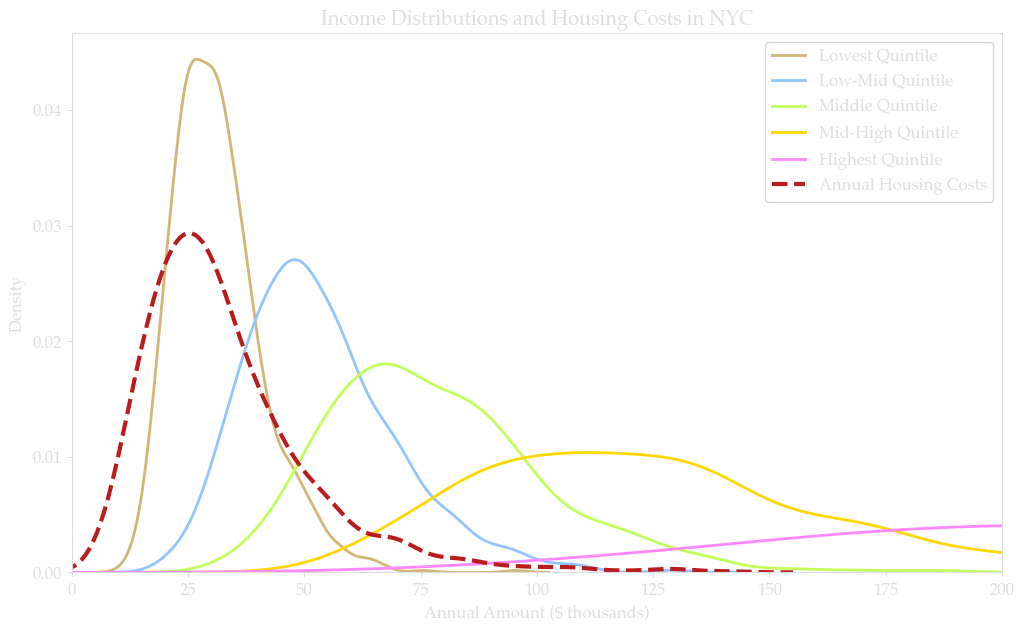

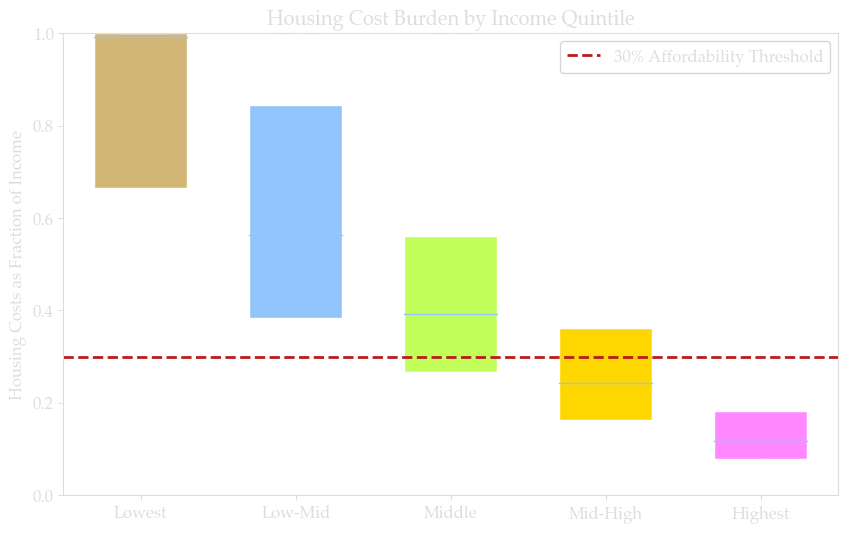

In [6]:
import seaborn as sns
# Simulate housing prices across neighborhoods
np.random.seed(42)
# Generate lognormal distributions for different income quintiles
n_households = 1000
income_quintiles = {
    'Lowest': np.random.lognormal(mean=np.log(30000), sigma=0.3, size=n_households),
    'Low-Mid': np.random.lognormal(mean=np.log(50000), sigma=0.3, size=n_households),
    'Middle': np.random.lognormal(mean=np.log(75000), sigma=0.3, size=n_households),
    'Mid-High': np.random.lognormal(mean=np.log(120000), sigma=0.3, size=n_households),
    'Highest': np.random.lognormal(mean=np.log(250000), sigma=0.4, size=n_households)
}

# Calculate affordable housing payments (30% of income)
affordable_housing = {quintile: income * 0.3 for quintile, income in income_quintiles.items()}

# Generate actual housing costs
housing_costs = np.random.lognormal(mean=np.log(30000), sigma=0.5, size=n_households)

# Plot income distributions and housing affordability
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#D1B675', '#93C5FD', '#C3FF5B', '#FFD700', '#FF88FF']

for i, (quintile, income) in enumerate(income_quintiles.items()):
    sns.kdeplot(income/1000, ax=ax, label=f'{quintile} Quintile', color=colors[i], linewidth=2)

# Plot housing cost distribution
sns.kdeplot(housing_costs/1000, ax=ax, label='Annual Housing Costs', color='#B91C1C', linewidth=3, linestyle='--')

ax.set_title('Income Distributions and Housing Costs in NYC')
ax.set_xlabel('Annual Amount ($ thousands)')
ax.set_ylabel('Density')
ax.set_xlim(0, 200)
ax.legend()
ax.grid(True, alpha=0.3)

# Create a second plot showing housing burden by income quintile
fig, ax = plt.subplots(figsize=(10, 6))
housing_burden = {quintile: np.minimum(housing_costs / income, 1) for quintile, income in income_quintiles.items()}

positions = range(1, 6)
box_data = [housing_burden[quintile] for quintile in ['Lowest', 'Low-Mid', 'Middle', 'Mid-High', 'Highest']]
box = ax.boxplot(box_data, positions=positions, patch_artist=True,
                widths=0.6, showfliers=False)

# Color the boxes
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

ax.axhline(y=0.3, color='#B91C1C', linestyle='--', linewidth=2, label='30% Affordability Threshold')
ax.set_title('Housing Cost Burden by Income Quintile')
ax.set_ylabel('Housing Costs as Fraction of Income')
ax.set_ylim(0, 1)
ax.set_xticks(positions)
ax.set_xticklabels(['Lowest', 'Low-Mid', 'Middle', 'Mid-High', 'Highest'])
ax.legend()
ax.grid(True, alpha=0.3)